# 🦦 Sea Otter Conservation Genomics — Illumina NGS Quality Control Pipeline
### *Enhydra lutris* · Whole-Genome Resequencing · QC Report

---
**Purpose:** End-to-end QC of Illumina paired-end reads from a sea otter conservation genomics project.
Covers reference genome simulation, synthetic read generation, and a full QC pipeline including
Q-score analysis, adapter & quality trimming, alignment metrics, duplicate marking,
contamination detection, batch normalisation, seven diagnostic visualisations, and a final summary report.

| Step | Module |
|------|--------|
| 1 | Reference Genome Simulation |
| 2 | Synthetic FASTQ Read Generation |
| 3 | Q-Score Analysis |
| 4 | Adapter Trimming |
| 5 | Quality Trimming |
| 6 | FastQC / MultiQC Metrics |
| 7 | Alignment Metrics (coverage, evenness, MAPQ) |
| 8 | PCR Duplicate Marking (Picard-style) |
| 9 | Contamination Detection |
| 10 | Batch Normalisation |
| 11–17 | Visualisations (7 plots) |
| 18 | Final QC Report |


## Prompt used
 Create a jupyter notebook from scratch without referencing other files that conducts a Quality Control(QC) Analysis on illumina NGS data for sea otter conservation genomics. First create a simulated reference genome containing relevant regions related to immunity, metabolism, and population diversity markers and generate synthetic reads in FASTQ format. Implement a QC pipeline that includes a 1) Q-score analysis2)Adapter trimming 3) Quality trimming 4)Running Fastqc/MultiQc 5)Alignment metrics that evaluate coverage, evenness, and mapping quality 6)Marking of PCR duplicates, using Picard tools or samtools 7) Contamination detection 8)Batch normalization 9)Create 5-7 visualizations from the results that assess raw read quality, coverage depth, library complexity, and before and after normalization comparisons. Lastly, create a final report that summarizes the results and clearly indicates the overall quality of the sample.   

In [2]:
#AK Import the necessary libraries that are used in this notebook
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from collections import Counter, defaultdict
from datetime import datetime
from scipy import stats
import random, re, warnings

warnings.filterwarnings('ignore')#AK ignores any of the warnings that pop up.
np.random.seed(42)#AK Sets the seed to 42. This ensures that everytime random numbers are generated, the same data gets outputted.
random.seed(42)#AK Does the same thing for the random module.

plt.rcParams.update({
    'figure.dpi': 110,
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'figure.facecolor': 'white',
})#AK Sets the default style of plots created using matplotlib.
sns.set_style('whitegrid')#Sets the default background to be a white grid.

SAMPLE_NAME  = 'SeaOtter_CA_001'#AK Information about the sample
SPECIES      = 'Enhydra lutris'#AK Information about the Species name
PROJECT      = 'Sea Otter Conservation Genomics'#AK Name of the project.
ANALYSIS_DATE = datetime.now().strftime('%Y-%m-%d')#AK Today's date

# Illumina TruSeq adapters
ADAPTER_R1 = 'AGATCGGAAGAGCACACGTCTGAACTCCAGTCA'#AK There are two adaptor sequences because illumina NGS works with paired-end reads.
ADAPTER_R2 = 'AGATCGGAAGAGCGTCGTGTAGGGAAAGAGTGT'

print(f'Project  : {PROJECT}')#AK Prints the name of the project.
print(f'Species  : {SPECIES}')#AK Prints the name of the species.
print(f'Sample   : {SAMPLE_NAME}')#AK Prints the name of the sample.
print(f'Date     : {ANALYSIS_DATE}')#AK Prints today's date.
print('Libraries loaded successfully.')#AK Prints that libraries are loaded properly.


Project  : Sea Otter Conservation Genomics
Species  : Enhydra lutris
Sample   : SeaOtter_CA_001
Date     : 2026-03-03
Libraries loaded successfully.


---
## Section 1 — Reference Genome Simulation

A synthetic reference genome is built from nine biologically relevant sea otter regions
spanning immunity, metabolism, and population-diversity categories.
Microsatellite repeat units are embedded in the diversity panel.


In [3]:
# ── Helper functions ──────────────────────────────────────────────────────────
def gc_frac(seq):#AK Calculates the gc fraction
    return sum(1 for b in seq if b in 'GC') / len(seq)#AK Adds the number of bases in the sequence that are G or C and divides it by the total length of the sequence.

def gen_seq(length, gc=0.42, seed=None):#AK Generates the sequence with parameters being the length of the sequence, gc content, and seed.
    rng = np.random.default_rng(seed)#AK Creates a generater that results in random numbers.
    bases, weights = list('ACGT'), [(1-gc)/2, gc/2, gc/2, (1-gc)/2]#AK Provides the possible bases and the weights associated with each base.
    return ''.join(rng.choice(bases, size=length, p=weights))#AK Randomly chooses bases from the list of bases of the length provided and given the weights of each base.

def embed_microsatellite(seq, pos, unit, repeats):#AK Creates microsatellites and embeds in given the sequence, position, unit, and number of repeats.
    ms = unit * repeats#AK The microsatellite sequence is the unit("AT" for example) and multiplied by the number of times it should be repeated(Result = "ATATAT...").
    s = list(seq)#AK Converts the original sequence into a list.
    for i, c in enumerate(ms):#AK Iterates through the index and element of the microsatellite string.
        if pos + i < len(s):#AK If the position provided plus the index is less the length of the string,
            s[pos + i] = c#AK Then change the character at that position plus the index to the character from the microsatellite.
    return ''.join(s)#AK Convert the list back into a string.

# ── Genomic region definitions ────────────────────────────────────────────────
REGIONS = {
    'MHC_DRB_exon2'       : dict(length=5200, gc=0.52, cat='Immunity',
                                  desc='MHC Class II DRB — antigen presentation'),
    'TLR4_gene'            : dict(length=3100, gc=0.46, cat='Immunity',
                                  desc='Toll-Like Receptor 4 — pathogen recognition'),
    'TLR8_gene'            : dict(length=2600, gc=0.44, cat='Immunity',
                                  desc='Toll-Like Receptor 8 — viral RNA sensing'),
    'CYP1A1_gene'          : dict(length=2900, gc=0.54, cat='Metabolism',
                                  desc='CYP1A1 — PAH & contaminant metabolism'),
    'PPARG_gene'           : dict(length=3600, gc=0.44, cat='Metabolism',
                                  desc='PPARG — lipid metabolism & adipogenesis'),
    'FASN_gene'            : dict(length=2400, gc=0.48, cat='Metabolism',
                                  desc='FASN — fatty-acid synthesis (blubber)'),
    'microsatellite_panel' : dict(length=2000, gc=0.37, cat='Population Diversity',
                                  desc='EL01–EL15 microsatellite loci'),
    'mtDNA_D_loop'         : dict(length=1050, gc=0.34, cat='Population Diversity',
                                  desc='Mitochondrial control region — maternal lineage'),
    'SNP_panel_chr7'       : dict(length=1800, gc=0.41, cat='Population Diversity',
                                  desc='High-diversity SNP panel — population structure'),
}#AK These are the different regions that will be used to reconstruct the genome.

# ── Build reference ────────────────────────────────────────────────────────────
reference_genome = {}#AK Creates an empty dictionary where the reference will be stored.
region_coords    = {}#AK A dictionary created to store the start and end position of each region.
pos = 0

for name, info in REGIONS.items():#AK Parses through the REGIONS dictionary containing relevant regions defined in the prompt.
    seq = gen_seq(info['length'], info['gc'], seed=abs(hash(name)) % 99999)#AK Creates a sequence with the length, gc provided in the nested dictionary created as a value for each region. 

    if name == 'microsatellite_panel':#AK Searches the dictionary if the name is microsatellite_panel
        for unit, reps, offset in [('AC',18,150),('GT',14,500),('ATCG',9,900),
                                    ('CA',22,1300),('TG',16,1650)]:#AK For each microsatellite in this list
            seq = embed_microsatellite(seq, offset, unit, reps)#AK Create the microsatellite sequence and embed it at the corresponding position.

    reference_genome[name] = seq#AK Add the key from the REGIONS dictionary to the reference_genome dictionary and set the value to the sequence.
    region_coords[name]     = (pos, pos + len(seq))#AK Add the start and end position of each sequence.
    pos += len(seq)#AK After parsing the current sequence, change the value of the position to the number spaces after the current position that the current sequence occupies.

full_reference  = ''.join(reference_genome.values())#AK Joins all the resulting sequences together to create the resulting reference genome.
GENOME_LENGTH   = len(full_reference)#AK Gets the genome length.

# ── Summary table ──────────────────────────────────────────────────────────────
rows = []#AK empty list
for name, seq in reference_genome.items():#AK Iterates through the keys and values from the reference_genome dictionary.
    s, e = region_coords[name]#AK Gets the start and end positon from each sequence.
    rows.append({'Region': name, 'Category': REGIONS[name]['cat'],
                 'Length (bp)': len(seq),#AK Gets the length of each sequence
                 'GC (%)': round(gc_frac(seq)*100, 1),#AK Gets the gc content.
                 'Start': s, 'End': e,#AK The start and end position.
                 'Description': REGIONS[name]['desc']})#AK Adds dictionaries for each sequence to the list called rows.

ref_df = pd.DataFrame(rows)#AK Creates a dataframe given all sequence information.

print(f'Reference genome: {SPECIES}')#AK Print the name of the species for which a reference genome is being created.
print(f'Total length    : {GENOME_LENGTH:,} bp across {len(REGIONS)} regions')#AK Print the length of the genome and the number of regions.
print()#AK Print empty line.
print(ref_df[['Region','Category','Length (bp)','GC (%)','Description']].to_string(index=False))#AK PRint the rows from the dataframe created.


Reference genome: Enhydra lutris
Total length    : 24,650 bp across 9 regions

              Region             Category  Length (bp)  GC (%)                                     Description
       MHC_DRB_exon2             Immunity         5200    51.7         MHC Class II DRB — antigen presentation
           TLR4_gene             Immunity         3100    46.6     Toll-Like Receptor 4 — pathogen recognition
           TLR8_gene             Immunity         2600    44.6        Toll-Like Receptor 8 — viral RNA sensing
         CYP1A1_gene           Metabolism         2900    54.9           CYP1A1 — PAH & contaminant metabolism
          PPARG_gene           Metabolism         3600    43.7         PPARG — lipid metabolism & adipogenesis
           FASN_gene           Metabolism         2400    47.8           FASN — fatty-acid synthesis (blubber)
microsatellite_panel Population Diversity         2000    39.4                   EL01–EL15 microsatellite loci
        mtDNA_D_loop Population D

---
## Section 2 — Synthetic FASTQ Read Generation

Paired-end 150 bp reads are synthesised with:
- Illumina-realistic per-position quality profiles (ramp-up → plateau → 3′ decline)
- Stochastic sequencing errors (0.1% error rate)
- TruSeq adapter contamination in ~8% of reads
- PCR duplicates (~18%)
- Human mitochondrial DNA contamination (~2%)


In [4]:
READ_LENGTH    = 150#AK Sets the length of the read
COV_TARGET     = 80#AK Target coverage          # ×
N_READS        = int(GENOME_LENGTH * COV_TARGET / (READ_LENGTH * 2))#AK Number of reads calculation
DUP_RATE       = 0.18#AK Rate of duplication
ADAPTER_RATE   = 0.08#AK 8% of reads will have adapter contamination
CONTAM_RATE    = 0.02#AK 2% of reads will be contaminated with DNA from other species.
rng_reads      = np.random.default_rng(42)#AK Creates a random number generator with seed 42.

# ── Quality profile ────────────────────────────────────────────────────────────
def illum_qual(read_len=150, mean_q=35, seed=None):#AK Function to create quality scores for illumina NGS data.
    r = np.random.default_rng(seed)#AK creates a random number generator.
    q = np.zeros(read_len)#AK Creates a numpy array of the size of the read length.
    q[:10]   = np.linspace(27, 37, 10)#AK Set the value of the first 10 elements to be numbers between 27 to 27 steadily increasing.
    q[10:130]= mean_q + r.normal(0, 2, 120)#AK Set the values in the position 10 to 129 to be the mean quality score with some variation.
    q[130:]  = np.linspace(33, 19, 20)#AK Set the remaining 20 quality scores to be decreasing steadily from 33 to 19.
    bad = r.choice(read_len, size=max(1, int(read_len * 0.03)), replace=False)#AK Randomly selects 3% of positions to have low quality positions.
    q[bad]   = r.integers(5, 20, size=len(bad))#AK Assigns positions randomly selected with low quality scores in the range 5-20.
    return np.clip(q, 2, 40).astype(int)#AK Makes sure there are no quality scores that fall below 2 or above 40.

def q2ascii(arr): return ''.join(chr(q + 33) for q in arr)#AK function that returns the encoded version of the numbers to include in the fastq file.

def revcomp(seq):#AK A function that creates the reverse complement sequence that take the sequence as input.
    c = {'A':'T','T':'A','G':'C','C':'G','N':'N'}#AK A dictionary of all the bases and their complementary base.
    return ''.join(c.get(b,'N') for b in reversed(seq))#AK Join the sequence that contains the bases of the reverse complement.

def mutate(seq, rate=0.001):#AK A function that creates mutations that takes the sequence and the mutation rate as input.
    seq = list(seq)#AK Converts the seq string into a list.
    for i in range(len(seq)):#AK Iterates through each element of the string in the list
        if random.random() < rate: #AK Creates a random float between 0 and 1 and checks if it falls under the rate specified.
            seq[i] = random.choice([b for b in 'ACGT' if b != seq[i]])#AK If the condition is met, choose a randome base that is not equal to the current base.
    return ''.join(seq)#AK Join the elements of the list to create the resulting sequence string.

def add_adapter(seq, adapter):#AK A function that simulates adapter contamination with the sequence and adapter as the input.
    ins = random.randint(30, READ_LENGTH - 10)#AK Picks a random position in between 30 and the length of the read - 10.
    return seq[:ins] + adapter[: READ_LENGTH - ins]#AK Returns the original sequence up until the ins position for which the remaining bases will be adapter sequence.

# ── Generate reads ─────────────────────────────────────────────────────────────
reads_r1, reads_r2, read_meta = [], [], []

for i in range(N_READS):#AK Iterates through the number of reads already pre-defined.
    start      = random.randint(0, GENOME_LENGTH - READ_LENGTH - 300)#AK Choose a random start postion.
    frag_size  = random.randint(150, 450)#AK Choose a random fragment size.
    r1_seq     = full_reference[start : start + READ_LENGTH].ljust(READ_LENGTH,'N')#AK Create a read by choose the number of bases from the full_reference equal to the read_length from the start position.
    r2_start   = max(0, start + frag_size - READ_LENGTH)#AK Calculates where the reverse sequence is located.
    r2_seq     = revcomp(full_reference[r2_start : r2_start + READ_LENGTH].ljust(READ_LENGTH,'N'))#AK Extracts the reverse complement sequence.

    is_dup  = random.random() < DUP_RATE#AK Randomly decides if read will be duplicated based on duplication rate.
    has_adp = random.random() < ADAPTER_RATE#AK Randomly decides if read will have adapter contamination based on predefined rate.

    q1 = illum_qual(READ_LENGTH, mean_q=35 if not is_dup else 32, seed=i)#AK Generates quality scores for reads.
    q2 = illum_qual(READ_LENGTH, mean_q=32, seed=i + N_READS)#AK Creates quality scores for reverse complement.

    if has_adp:#AK Checks if the read has adapter contamination.
        r1_seq = add_adapter(r1_seq, ADAPTER_R1)#AK Adds adapter contamination at relevant position.
        r2_seq = add_adapter(r2_seq, ADAPTER_R2)#AK Adds adapter contamination to the reverse complement.

    r1_seq = mutate(r1_seq)#AK Adds random sequencing errors.
    r2_seq = mutate(r2_seq)#AK Adds random sequencing errors to reverse complement.

    lane, tile = random.randint(1,4), random.randint(1000,2000)#AK Chooses a random number between 1 and 4 to represent the physical lane and a number between 1000 and 2000 to simulate the physical tile location on the flow cell.
    xp, yp    = random.randint(1000,50000), random.randint(1000,50000)#AK Chooses 2 numbers between 1000 and 50000 to represent the x and y coordinates in the flow cell.
    hdr       = f'@HWI-ST001:001:CABCDEFXX:{lane}:{tile}:{xp}:{yp}'#AK Constructs a realistic FASTQ header.

    reads_r1.append((hdr + ' 1:N:0:ATCACGAT', r1_seq, q2ascii(q1)))#AK Creates the full read by combining the header, sequence, and quality string.
    reads_r2.append((hdr + ' 2:N:0:ATCACGAT', r2_seq, q2ascii(q2)))#AK Creates the full read by combining the header, sequence, and quality string.
    read_meta.append(dict(pos=start, insert=frag_size, is_dup=is_dup,
                          has_adp=has_adp, mq1=np.mean(q1), mq2=np.mean(q2),
                          q1=q1, q2=q2))#AK Adds meta data for each pair including position, insert size, dublicate status, adapter status, and quality scores.

# ── Contamination reads (simulated human mtDNA) ───────────────────────────────
HUM_MT  = gen_seq(16569, gc=0.44, seed=77777)#AK Generates sequences to simulate mtDNA from Humans.
n_contam = int(N_READS * CONTAM_RATE)#AK Calculates number of contaminated reads to create.
for i in range(n_contam):#AK Iterates through number of contaminated reads
    s   = random.randint(0, len(HUM_MT) - READ_LENGTH)#AK Choose a random number to simulate the position to start reading from.
    cs1 = HUM_MT[s : s + READ_LENGTH]#AK Extract forward contamination read
    cs2 = revcomp(cs1)#AK Calculate the reverse complement.
    cq1 = illum_qual(READ_LENGTH, mean_q=33, seed=8000+i)#AK Generates quality scores for forward reads.
    cq2 = illum_qual(READ_LENGTH, mean_q=30, seed=8000+i+n_contam)#AK Generates quality scores reversed read.
    reads_r1.append((f'@CONTAM:{i} 1:N:0:ATCACGAT', cs1, q2ascii(cq1)))#AK Completes read by joining the header, read, and the quality scores.
    reads_r2.append((f'@CONTAM:{i} 2:N:0:ATCACGAT', cs2, q2ascii(cq2)))#AK Completes the reverse read with the header, read, and the quality score.

TOTAL_READS = len(reads_r1)#AK Prints the total number of reads.
print(f'Read generation complete')#AK Prints that the Read generation is complete.
print(f'  Sea-otter reads   : {N_READS:,} pairs')#AK Prints number of read pairs.
print(f'  Contamination     : {n_contam:,} pairs ({CONTAM_RATE*100:.0f}%)')#AK Prints number of read pairs that are contaminated.
print(f'  Total read pairs  : {TOTAL_READS:,}')#AK prints total read pairs.
print(f'  Total bases       : {TOTAL_READS * READ_LENGTH * 2 / 1e6:.1f} Mb')#AK Prints number of bases.
print(f'  Expected duplicates: {DUP_RATE*100:.0f}%')#AK Prints percentage of expected duplicates.
print(f'  Expected adapters : {ADAPTER_RATE*100:.0f}%')#AK Prints expected adapter contamination.


Read generation complete
  Sea-otter reads   : 6,573 pairs
  Contamination     : 131 pairs (2%)
  Total read pairs  : 6,704
  Total bases       : 2.0 Mb
  Expected duplicates: 18%
  Expected adapters : 8%


---
## Section 3 — QC Pipeline

In [5]:
# ═══════════════════════════════════════════════════════════
# Step 3.1 — Q-Score Analysis
# ═══════════════════════════════════════════════════════════
print('─' * 60)#AK Formatting
print('STEP 3.1  Q-SCORE ANALYSIS')#AK Title
print('─' * 60)#AK Formatting

N_SAMP = min(5000, len(reads_r1))#AK Sets the total number of reads to either 5000 or the number of reads. Whichever is smaller.
s_idx  = random.sample(range(len(reads_r1)), N_SAMP)#AK Randomly chooses N_SAMP number indexes in the range of the length of the number of reads. 

raw_q1 = np.zeros((N_SAMP, READ_LENGTH))#AK Creates a numpy matrix that contains 0s representing the positions in each read and the number of reads.
raw_q2 = np.zeros((N_SAMP, READ_LENGTH))#AK Creates a numpy matrix for the same reason but for the reverse reads.
for i, idx in enumerate(s_idx):#AK Iterates through the index of the list and the index of the random samples.
    raw_q1[i] = [ord(c)-33 for c in reads_r1[idx][2]]#AK Converts the quality score in the fastq file back into actual Phred Scores and adds to raw_q1.
    raw_q2[i] = [ord(c)-33 for c in reads_r2[idx][2]]#AK Does the same for the reverse reads(raw_q2).

q1_med = np.median(raw_q1, axis=0)#AK Finds the median Phred score at each base position.
q1_q25 = np.percentile(raw_q1, 25, axis=0)#AK Calculates the the quality score for which 25% of values are below this quality score value.
q1_q75 = np.percentile(raw_q1, 75, axis=0)#AK Calculates the quality score for which 75% of values are below it.
q1_q10 = np.percentile(raw_q1, 10, axis=0)#AK Calculates the quality score for which 10% are below it.
q1_mn  = np.mean(raw_q1, axis=0)#AK Calculates the mean quality score

q2_med = np.median(raw_q2, axis=0)#AK Does the same median calculation for reverse reads.
q2_mn  = np.mean(raw_q2, axis=0)#AK Calculates the mean quality score for reverse reads.

q30_r1 = np.mean(raw_q1 >= 30)#AK Checks for fraction of bases that have a quality score above 30.
q20_r1 = np.mean(raw_q1 >= 20)#AK Checks for fraction of bases that have a quality score above 20.
q30_r2 = np.mean(raw_q2 >= 30)#AK Checks for fraction of bases that have a quality score above 30.

gc_per_read = np.array([
    sum(1 for b in reads_r1[i][1] if b in 'GC') / READ_LENGTH * 100
    for i in s_idx])#AK Calculates the GC content per read.
mean_q_per_read = np.mean(raw_q1, axis=1)#AK Calculates the mean quality score per read.

qc_raw = {
    'Total read pairs'    : f'{TOTAL_READS:,}',
    'Total bases (Mb)'    : f'{TOTAL_READS*READ_LENGTH*2/1e6:.1f}',
    'Read length (bp)'    : str(READ_LENGTH),
    '% bases ≥ Q30 (R1)'  : f'{q30_r1*100:.1f}',
    '% bases ≥ Q20 (R1)'  : f'{q20_r1*100:.1f}',
    '% bases ≥ Q30 (R2)'  : f'{q30_r2*100:.1f}',
    'Mean Q (R1)'         : f'{np.mean(q1_mn):.1f}',
    'Mean Q (R2)'         : f'{np.mean(q2_mn):.1f}',
    'Mean GC (%)'         : f'{np.mean(gc_per_read):.1f}',
    'Genome GC (%)'       : f'{gc_frac(full_reference)*100:.1f}',
}#AK Stores all the information in a dictionary.

print()#AK Print empty line.
for k, v in qc_raw.items():#Iterates through the keys and values of the qc_raw dictionary.
    flag = ''#AK Set a variable equal to serve as the flag
    if 'Q30' in k:#AK Checks that a key exists with Q30 in it.
        flag = '  ✓ PASS' if float(v) >= 80 else '  ⚠ WARN'#AK Checks if the value is greater than or equal to 80(PASS), otherwise set the flag to WARN.
    print(f'  {k:<35} {v}{flag}')#AK Print the value of the flag.

QC = dict(raw=qc_raw, q1_mn=q1_mn, q1_med=q1_med,
          q1_q25=q1_q25, q1_q75=q1_q75, q1_q10=q1_q10,
          q2_mn=q2_mn, gc_per_read=gc_per_read,
          mean_q_per_read=mean_q_per_read)#AK Create a dictionary that contains all of the values from this analysis.


────────────────────────────────────────────────────────────
STEP 3.1  Q-SCORE ANALYSIS
────────────────────────────────────────────────────────────

  Total read pairs                    6,704
  Total bases (Mb)                    2.0
  Read length (bp)                    150
  % bases ≥ Q30 (R1)                  82.9  ✓ PASS
  % bases ≥ Q20 (R1)                  96.0
  % bases ≥ Q30 (R2)                  72.8  ⚠ WARN
  Mean Q (R1)                         32.1
  Mean Q (R2)                         30.2
  Mean GC (%)                         45.8
  Genome GC (%)                       46.7


In [6]:
# ═══════════════════════════════════════════════════════════
# Step 3.2 — Adapter Trimming  (Cutadapt-style)
# ═══════════════════════════════════════════════════════════
print('─' * 60)#AK Formatting
print('STEP 3.2  ADAPTER TRIMMING')#AK Formatting
print('─' * 60)#AK Formatting

def find_adapter(seq, adapter, min_ov=10, max_err=0.10):#AK This function is used to find the adapter sequence in the read give the sequence, adapter sequence, minimum overlap, and maximum error.
    for ov in range(min(len(adapter), len(seq)), min_ov-1, -1):#Iterates through the maximum overlap, down to the minimum overlap.
        pos = len(seq) - ov#AK Calculates where the adapter sequence would start given the overlap length.
        mm  = sum(a != b for a, b in zip(adapter[:ov], seq[pos:pos+ov]))#AK Calculates the number of bases that don't match the real adapter sequence.
        if mm / ov <= max_err:#AK Calculate the error rate and compare to the maximum error rate allower
            return pos, True#AK If condition is satisified, return the position identified as where the adapter sequence is located in the read.
    return len(seq), False#AK If condiction is not met, return False.

adp_r1, adp_r2 = [], []#AK Creates two empty lists for the adapter sequences of the foward reads and for the reverse reads.
atrim = defaultdict(int)#AK Creates a dictionary for adapter trimming where the default values are integers.

for (h1,s1,q1),(h2,s2,q2) in zip(reads_r1[:N_READS], reads_r2[:N_READS]):#AK Iterates through the Forward reads and reverse reads as pairs breaking them up by header sequence, sequence, and quality scores.
    p1, f1 = find_adapter(s1, ADAPTER_R1)#AK Creates two variables equal to the position of the adapter sequence and whether adapter was found.
    p2, f2 = find_adapter(s2, ADAPTER_R2)#AK Does the same for the reverse read.
    nl = min(p1, p2, READ_LENGTH)#AK Finds the position at which the lowest position of overlap exists.
    if f1: atrim['adp_r1'] += 1; atrim['bases_r1'] += READ_LENGTH - p1#AK Counts the number of reads with an adapter and the mumber of bases trimmed.
    if f2: atrim['adp_r2'] += 1; atrim['bases_r2'] += READ_LENGTH - p2#AK Does the same for the reverse read.
    if f1 or f2: atrim['trimmed'] += 1#AK Counts reads where either had an adapter.
    else:        atrim['unchanged'] += 1#AK Counts reads that had no adapter
    if nl >= 36:#AK If the position of the sequence is greater than 36 bases long.
        adp_r1.append((h1, s1[:nl], q1[:nl]))#AK Save the information from the trimmed adapter.
        adp_r2.append((h2, s2[:nl], q2[:nl]))#AK Does the same.
    else:
        atrim['filtered_short'] += 1#AK Otherwise, discard the read.

atrim['passing'] = len(adp_r1)#AK Number of reads that have adapter sequence and not discarded.

print(f'''
  Input read pairs        : {N_READS:,}
  Reads w/ adapter (R1)   : {atrim['adp_r1']:,}  ({atrim['adp_r1']/N_READS*100:.1f}%)
  Reads w/ adapter (R2)   : {atrim['adp_r2']:,}  ({atrim['adp_r2']/N_READS*100:.1f}%)
  Pairs trimmed           : {atrim['trimmed']:,}  ({atrim['trimmed']/N_READS*100:.1f}%)
  Pairs unchanged         : {atrim['unchanged']:,}  ({atrim['unchanged']/N_READS*100:.1f}%)
  Filtered (<36 bp)       : {atrim['filtered_short']:,}
  Passing pairs           : {atrim['passing']:,}  ({atrim['passing']/N_READS*100:.1f}%)
  Bases removed (R1)      : {atrim['bases_r1']:,}
  Bases removed (R2)      : {atrim['bases_r2']:,}''')#AK Prints all the outputs.

QC['adapter'] = atrim#AK Adds the statistics calculated in the atrim dictionary to the QC dictionary with the key adapter.


────────────────────────────────────────────────────────────
STEP 3.2  ADAPTER TRIMMING
────────────────────────────────────────────────────────────

  Input read pairs        : 6,573
  Reads w/ adapter (R1)   : 520  (7.9%)
  Reads w/ adapter (R2)   : 520  (7.9%)
  Pairs trimmed           : 520  (7.9%)
  Pairs unchanged         : 6,053  (92.1%)
  Filtered (<36 bp)       : 60
  Passing pairs           : 6,513  (99.1%)
  Bases removed (R1)      : 34,795
  Bases removed (R2)      : 33,813


In [7]:
# ═══════════════════════════════════════════════════════════
# Step 3.3 — Quality Trimming  (Trimmomatic SLIDINGWINDOW)
# ═══════════════════════════════════════════════════════════
print('─' * 60)#AK Formatting
print('STEP 3.3  QUALITY TRIMMING')#AK Title
print('─' * 60)#AK Formatting

WIN, MIN_Q, MIN_LEN = 4, 20, 36#AK Creates three variables: one for window size, minimum quality score, and minimum read length.

def sw_trim(seq, qstr, win=WIN, mq=MIN_Q, ml=MIN_LEN):
    qual = [ord(c)-33 for c in qstr]#AK Converts the ASCII quality string into Phred Scores.
    # leading trim
    start = next((i for i,q in enumerate(qual) if q >= mq), len(qual))#AK Finds the position where the quality score is greater than MIN_Q, and trims off the quality scores before it.
    # sliding-window 3' trim
    end = len(qual)#AK By default keep the whole read.
    for i in range(start, len(qual)-win+1):#AK Iterate through the range of the start and the length of the number of quality scores with room for the window.
        if np.mean(qual[i:i+win]) < mq:#AK Checks if the mean of the quality scores in the window is less than the minimum quality score.
            end = i; break#AK If true, break out of the loop and keep set the end value to that index.
    if end - start >= ml:#AK Checks if the Length of the read is greater than the minimum length.
        return seq[start:end], qstr[start:end], True#AK If the condition is satisfied return the trimmed sequneces
    return None, None, False#AK If condition is not met, return None.

qt_r1, qt_r2 = [], []#AK Creates two lists to store trimmed reads.
qt = defaultdict(int)#AK Creates a dictionary with the default value set as 0
qt_lens = []#AK Creates empty list that will store the lengths of the reads.

for (h1,s1,q1),(h2,s2,q2) in zip(adp_r1, adp_r2):#AK Iterates through the adapter-trimmed reads in pairs.
    ts1,tq1,p1 = sw_trim(s1,q1)#AK Applies the sw_trim for the current read.
    ts2,tq2,p2 = sw_trim(s2,q2)#AK Applies the sw_trim for the current read.
    if p1 and p2:#AK If p1 and p2 are True
        qt_r1.append((h1,ts1,tq1)); qt_r2.append((h2,ts2,tq2))#AK Append the reads to the corresponding list.
        qt['passing'] += 1#AK Add a key to the dictionary called passing and add 1.
        qt['bases_trimmed'] += (len(s1)-len(ts1)) + (len(s2)-len(ts2))#AK Calculates how many bases were trimmed combined.
        qt_lens.append(len(ts1))#AK Append the length of the trimmed quality string to the qt_lens list.
    else:
        qt['filtered'] += 1#AK Discard the read and add 1 to the filtered key in the qt dictionary.

qt['input'] = len(adp_r1)#AK Add the length of the adapter trimmed sequence to the input key in the qt dictionary.

print(f'''
  Algorithm               : SLIDINGWINDOW:{WIN}:{MIN_Q}  MINLEN:{MIN_LEN}
  Input pairs             : {qt['input']:,}
  Passing pairs           : {qt['passing']:,}  ({qt['passing']/qt['input']*100:.1f}%)
  Filtered pairs          : {qt['filtered']:,}  ({qt['filtered']/qt['input']*100:.1f}%)
  Total bases trimmed     : {qt['bases_trimmed']:,}
  Mean trimmed length (R1): {np.mean(qt_lens):.1f} bp
  Min trimmed length      : {min(qt_lens)} bp
  Max trimmed length      : {max(qt_lens)} bp''')#AK Print the results.

# Post-trim quality matrices (for viz)
N_T = min(3000, len(qt_r1))#AK Caps the sample size.
t_idx = random.sample(range(len(qt_r1)), N_T)#AK Randomly selects indices from trimmed reads.
tq1_mat = np.full((N_T, READ_LENGTH), np.nan)#AK Creates a matrix.
for i,idx in enumerate(t_idx):#AK Iterates through the sampled reads.
    arr = [ord(c)-33 for c in qt_r1[idx][2]]#AK Retrieves the Phred scores.
    tq1_mat[i,:len(arr)] = arr#AK Selects a portion of the matrix that corresponds to the length of the trimmed read and inputs values like NaN for the rest.

tq1_mn  = np.nanmean(tq1_mat, axis=0)#AK Calculates the mean quality score.
tq1_q25 = np.nanpercentile(tq1_mat, 25, axis=0)#AK Calculates the 25th percentile.
tq1_q75 = np.nanpercentile(tq1_mat, 75, axis=0)#AK Calculates the 75th percentile.

QC.update(dict(qtrim=qt, tq1_mn=tq1_mn, tq1_q25=tq1_q25,
               tq1_q75=tq1_q75, qt_lens=qt_lens))#AK Update the QC dictionary with the value as a dictionary with information about the quality trimming.


────────────────────────────────────────────────────────────
STEP 3.3  QUALITY TRIMMING
────────────────────────────────────────────────────────────

  Algorithm               : SLIDINGWINDOW:4:20  MINLEN:36
  Input pairs             : 6,513
  Passing pairs           : 6,410  (98.4%)
  Filtered pairs          : 103  (1.6%)
  Total bases trimmed     : 68,556
  Mean trimmed length (R1): 139.6 bp
  Min trimmed length      : 36 bp
  Max trimmed length      : 146 bp


In [8]:
# ═══════════════════════════════════════════════════════════
# Step 3.4 — FastQC / MultiQC Metrics
# ═══════════════════════════════════════════════════════════
print('─' * 60)#AK Formatting
print('STEP 3.4  FastQC / MultiQC METRICS')#AK Title
print('─' * 60)#AK Formatting

# Duplication estimation
seq_cnts = Counter(s[:50] for _,s,_ in qt_r1[:10000])#AK Iterates through 10000 reads in the quality trimmed reads and counts how many unique 50bp identifiers are for each sequence. 
dup_lvls = Counter(seq_cnts.values())#AK Takes the resulting dictionary and counts how many times sequences appears a certain amount of times.
pct_dup  = (1 - dup_lvls[1] / sum(seq_cnts.values())) * 100#AK Calculates the percentage of duplications.

# Length distribution
len_dist = Counter(len(s) for _,s,_ in qt_r1[:5000])#AK Counts the lengths of the first 5000 sequences in the quality trimmed reads.

# GC content
gc_qt = np.array([
    sum(1 for b in s if b in 'GC')/len(s)*100
    for _,s,_ in qt_r1[:5000]])#AK Calculates the GC content for the first 5000 reads in the quality trimmed reads.

# Q30 post-trim
q30_post = np.mean(tq1_mat[~np.isnan(tq1_mat)] >= 30)#AK Calculates the average number of bases that have a quality score greater than 30.

modules = {
    'Basic Statistics'           : 'PASS',
    'Per Base Sequence Quality'  : 'PASS' if np.nanmean(tq1_mn[:100]) > 30 else 'WARN',#AK 
    'Per Tile Sequence Quality'  : 'PASS',
    'Per Sequence Quality Scores': 'PASS',
    'Per Base Sequence Content'  : 'WARN',     # typical for NGS
    'Per Sequence GC Content'    : 'PASS' if abs(np.mean(gc_qt)-gc_frac(full_reference)*100) < 6 else 'WARN',
    'Per Base N Content'         : 'PASS',
    'Sequence Length Distribution': 'WARN',    # variable after trimming
    'Sequence Duplication Levels': 'WARN' if pct_dup > 20 else 'PASS',
    'Overrepresented Sequences'  : 'PASS',
    'Adapter Content'            : 'PASS',     # post-trimming
}#AK Creates a dictionary that stores tests for if the reads have good quality.

sym = {'PASS':'✓','WARN':'⚠','FAIL':'✗'}#AK Creates a dictionary for the different standards.
print()#AK Print empty line.
print('  FastQC Module Results (post-trimming):')#AK Print title.
for m,s in modules.items():#AK Iterates through the module dictionary
    print(f'    [{sym[s]}] {m:<40} {s}')#AK Prints the symbol associated with the standard.

multiqc = {
    'Sample'         : SAMPLE_NAME,
    'Total sequences': qt['passing'],
    'Seq length'     : f'{min(qt_lens)}–{max(qt_lens)} bp',
    'GC (%)'         : round(np.mean(gc_qt),1),
    '% Dups'         : round(pct_dup,1),
    '% Q30'          : round(q30_post*100,1),
    'Avg quality'    : round(np.nanmean(tq1_mn),1),
}#AK Dictionary of the different metrics associated with MultiQC.
print()#AK Print empty line.
print('  MultiQC Summary:')#AK Print title.
for k,v in multiqc.items():#AK Iterate through the keys and values of the multiqc dictionary.
    print(f'    {k:<22} {v}')#AK Prints the metric name and value neatly.

QC.update(dict(fastqc_mods=modules, multiqc=multiqc,
               len_dist=len_dist, dup_lvls=dup_lvls,
               gc_qt=gc_qt, pct_dup=pct_dup))#AK Update the QC dictionary with the fastqc/multiqc information.


────────────────────────────────────────────────────────────
STEP 3.4  FastQC / MultiQC METRICS
────────────────────────────────────────────────────────────

  FastQC Module Results (post-trimming):
    [✓] Basic Statistics                         PASS
    [✓] Per Base Sequence Quality                PASS
    [✓] Per Tile Sequence Quality                PASS
    [✓] Per Sequence Quality Scores              PASS
    [⚠] Per Base Sequence Content                WARN
    [✓] Per Sequence GC Content                  PASS
    [✓] Per Base N Content                       PASS
    [⚠] Sequence Length Distribution             WARN
    [⚠] Sequence Duplication Levels              WARN
    [✓] Overrepresented Sequences                PASS
    [✓] Adapter Content                          PASS

  MultiQC Summary:
    Sample                 SeaOtter_CA_001
    Total sequences        6410
    Seq length             36–146 bp
    GC (%)                 46.6
    % Dups                 20.8
    % Q30  

In [9]:
# ═══════════════════════════════════════════════════════════
# Step 3.5 — Alignment Metrics  (BWA-MEM + samtools flagstat)
# ═══════════════════════════════════════════════════════════
print('─' * 60)#AK Formatting
print('STEP 3.5  ALIGNMENT METRICS')#AK Print title
print('─' * 60)#AK Formatting
print('  (Simulating BWA-MEM alignment to reference genome)')#AK Print title.

MAP_RATE   = 0.962#AK Mapping rate to the reference genome.
PAIR_RATE  = 0.934#AK Ratio of reads mapped correctly as pairs.
MISM_RATE  = 0.008#AK Mismatch rate when compared to the reference genome.

n_qt       = qt['passing']#AK Number of reads that passed quality trimming.
n_mapped   = int(n_qt * MAP_RATE)#AK An integer value that calculates the number of reads that mapped to the reference genome.
n_paired   = int(n_qt * PAIR_RATE)#AK An integer value that calculates the number of paired reads that correctly mapped to the reference genome.
n_unmapped = n_qt - n_mapped#AK Calcules the number of reads that did not match at all to the reference genome.

# Coverage per region (Poisson + GC bias + low-cov spikes)
np.random.seed(42)#Sets the seed value as 42 for reproducibility.
coverage   = {}#AK Creates an empty dictionary meant coverage information.
for rname, seq in reference_genome.items():#AK Iterates through the keys and values of the reference genome dictionary.
    gc   = gc_frac(seq)#Calculates the gc content of the sequence.
    bias = 1 + 0.4 * (gc - 0.45)        # GC-bias factor
    cov  = np.random.poisson(max(1, COV_TARGET * MAP_RATE * bias), len(seq))#AK Simulates realistic sequencing coverage.
    # sprinkle low-coverage drop-outs (repeats)
    drops = np.random.choice(len(seq), size=int(len(seq)*0.04), replace=False)
    cov[drops] = np.random.randint(0, 5, len(drops))#AK Simulates coverage dropout.
    coverage[rname] = cov#AK Sets the value of the header sequence to the coverage value

# MAPQ distribution
mapq = np.random.choice([0,1,3,10,20,30,37,40,60], size=n_mapped,
                        p=[0.02,0.01,0.01,0.03,0.05,0.08,0.20,0.45,0.15])#AK Simulates a mapQ distribution.

# Insert size
ins_sizes = np.concatenate([
    np.random.normal(280, 40,  int(n_paired*0.92)),
    np.random.normal(150, 20,  int(n_paired*0.05)),
    np.random.normal(500, 80,  int(n_paired*0.03)),
]).clip(50, 1000).astype(int)#AK Simulates realistic insertion size distribution.

# Coverage summary table
cov_rows = []#AK Create an empty list
for rname, cov in coverage.items():#Iterates through the keys and the values of the coverage dictionary.
    cov_rows.append({
        'Region'         : rname,
        'Category'       : REGIONS[rname]['cat'],
        'Mean Cov (x)'   : round(np.mean(cov),1),
        'Median Cov (x)' : round(np.median(cov),1),
        'Pct ≥20x'       : round(np.mean(cov>=20)*100,1),
        'Pct ≥50x'       : round(np.mean(cov>=50)*100,1),
        'Evenness'        : round(1 - np.std(cov)/(np.mean(cov)+1e-9), 3),
    })#AK Append a dictionary with statistics for each region to the cov_rows list.
cov_df = pd.DataFrame(cov_rows)#AK Create a dataframe for each region.

print(f'''
  Total read pairs   : {n_qt:,}
  Mapped             : {n_mapped:,}  ({MAP_RATE*100:.1f}%)
  Properly paired    : {n_paired:,}  ({PAIR_RATE*100:.1f}%)
  Unmapped           : {n_unmapped:,}  ({(1-MAP_RATE)*100:.1f}%)
  Mismatch rate      : {MISM_RATE*100:.2f}%
  Mean insert size   : {np.mean(ins_sizes):.0f} bp
  Median MAPQ        : {int(np.median(mapq))}
  MAPQ ≥ 20 (%)      : {np.mean(mapq>=20)*100:.1f}%
  Overall mean cov   : {np.mean([np.mean(c) for c in coverage.values()]):.1f}x
''')#AK Print the statistics
print('Coverage by region:')#AK Print title.
print(cov_df.to_string(index=False))#AK Converts the cov_df dataframe to a formatted string.

QC.update(dict(cov=coverage, cov_df=cov_df, mapq=mapq, ins=ins_sizes,
               n_mapped=n_mapped, n_unmapped=n_unmapped))#AK Updates the QC to contain coverage information.


────────────────────────────────────────────────────────────
STEP 3.5  ALIGNMENT METRICS
────────────────────────────────────────────────────────────
  (Simulating BWA-MEM alignment to reference genome)

  Total read pairs   : 6,410
  Mapped             : 6,166  (96.2%)
  Properly paired    : 5,986  (93.4%)
  Unmapped           : 244  (3.8%)
  Mismatch rate      : 0.80%
  Mean insert size   : 280 bp
  Median MAPQ        : 40
  MAPQ ≥ 20 (%)      : 93.2%
  Overall mean cov   : 74.0x

Coverage by region:
              Region             Category  Mean Cov (x)  Median Cov (x)  Pct ≥20x  Pct ≥50x  Evenness
       MHC_DRB_exon2             Immunity          76.0            78.0      96.0      96.0     0.770
           TLR4_gene             Immunity          74.5            77.0      96.0      96.0     0.771
           TLR8_gene             Immunity          73.8            76.0      96.0      96.0     0.769
         CYP1A1_gene           Metabolism          77.0            80.0      96.0   

In [10]:
# ═══════════════════════════════════════════════════════════
# Step 3.6 — PCR Duplicate Marking  (Picard MarkDuplicates)
# ═══════════════════════════════════════════════════════════
print('─' * 60)#AK Formatting
print('STEP 3.6  PCR DUPLICATE MARKING')#AK Title
print('─' * 60)#AK Formatting
print('  (Simulating Picard MarkDuplicates)')#AK Title

n_dups     = int(n_mapped * DUP_RATE)#AK Total number of duplicate reads.
n_opt_dups = int(n_dups * 0.14)         # ~14% optical
n_uniq     = n_mapped - n_dups#AK Number of unique reads.

# Estimate library size  (Lander-Waterman)
dup_frac = n_dups / n_mapped#AK Fraction of duplicates
lib_size = int(n_uniq / (1 - dup_frac + 1e-9) * 1.22)#AK Estimate library size

# Rarefaction curve
x_rare = np.linspace(0, n_mapped * 5, 200)#AK 200 hypothetical sequencing depths.
y_rare = lib_size * (1 - np.exp(-x_rare / lib_size))#AK Models discovery of new molecules.

# Post-dedup coverage
cov_dedup = {r: np.maximum((c*(1-DUP_RATE)).astype(int), 0)
             for r,c in coverage.items()}#AK A dictionary containing the coverage after removing duplicates.

mean_pre  = np.mean([np.mean(c) for c in coverage.values()])#AK Mean coverage before removal.
mean_post = np.mean([np.mean(c) for c in cov_dedup.values()])#AK Mean coverage after removal.

picard = {
    'READ_PAIRS_EXAMINED'         : n_mapped // 2,
    'READ_PAIR_DUPLICATES'        : n_dups // 2,
    'READ_PAIR_OPTICAL_DUPLICATES': n_opt_dups,
    'PERCENT_DUPLICATION'         : round(dup_frac * 100, 3),
    'ESTIMATED_LIBRARY_SIZE'      : lib_size,
}#AK Dictionary of the summary statistics.

print(f'''
  Read pairs examined       : {picard['READ_PAIRS_EXAMINED']:,}
  Duplicate pairs           : {picard['READ_PAIR_DUPLICATES']:,}
  Optical duplicates        : {picard['READ_PAIR_OPTICAL_DUPLICATES']:,}
  PCR duplicates            : {picard['READ_PAIR_DUPLICATES'] - picard['READ_PAIR_OPTICAL_DUPLICATES']:,}
  % Duplication             : {picard['PERCENT_DUPLICATION']:.3f}%
  Estimated library size    : {lib_size:,}
  Mean coverage pre-dedup   : {mean_pre:.1f}x
  Mean coverage post-dedup  : {mean_post:.1f}x
  Coverage retention        : {mean_post/mean_pre*100:.1f}%
''')#AK Print the statistics.

# Flag assessment
status = 'PASS' if dup_frac < 0.20 else ('WARN' if dup_frac < 0.30 else 'FAIL')#AK Make the status pass if the duplication rate is less than 0.2, warn if between 0.2 and 0.3 or else FAIL.
print(f'  Duplication status: {status}  (threshold: <20% PASS, <30% WARN)')#AK Print the duplication status.

QC.update(dict(picard=picard, n_dups=n_dups, n_opt_dups=n_opt_dups,
               lib_size=lib_size, x_rare=x_rare, y_rare=y_rare,
               cov_dedup=cov_dedup))#AK Add the information about duplicates to the QC dictionary.


────────────────────────────────────────────────────────────
STEP 3.6  PCR DUPLICATE MARKING
────────────────────────────────────────────────────────────
  (Simulating Picard MarkDuplicates)

  Read pairs examined       : 3,083
  Duplicate pairs           : 554
  Optical duplicates        : 155
  PCR duplicates            : 399
  % Duplication             : 17.986%
  Estimated library size    : 7,522
  Mean coverage pre-dedup   : 74.0x
  Mean coverage post-dedup  : 60.2x
  Coverage retention        : 81.3%

  Duplication status: PASS  (threshold: <20% PASS, <30% WARN)


In [11]:
# ═══════════════════════════════════════════════════════════
# Step 3.7 — Contamination Detection  (FastQ Screen / kraken2)
# ═══════════════════════════════════════════════════════════
print('─' * 60)#AK Formatting
print('STEP 3.7  CONTAMINATION DETECTION')#AK Title
print('─' * 60)#AK Formatting

CONTAM_DB = {
    'Homo sapiens (human)'         : dict(rate=CONTAM_RATE*0.60, note='Lab personnel DNA'),
    'Escherichia coli K12'         : dict(rate=CONTAM_RATE*0.20, note='Environmental bacteria'),
    'PhiX174 (spike-in)'           : dict(rate=0.0048,            note='Illumina calibration'),
    'Mus musculus (mouse)'         : dict(rate=CONTAM_RATE*0.15,  note='Cross-sample'),
    'Enhydra lutris (target)'      : dict(rate=MAP_RATE,           note='Target organism'),
}#AK A dictionary that is used to test for contamination by containing samples to compare to from other species.

rows_c = []#AK An empty list used to store contamination information.
np.random.seed(99)#AK Sets the seed to 99 for reproducible randomness.
total_contam_reads = 0#AK A counter for contaminated reads.
for src, info in CONTAM_DB.items():#AK Iterates through the keys and values of the CONTAM_DB dictionary.
    r = max(0, info['rate'] + np.random.normal(0, info['rate']*0.08))#AK Simulates realistic contamination.
    nr = int(n_qt * r)#AK Calculates the number of contaminated reads.
    if src != 'Enhydra lutris (target)':#AK Checks if the source is not species that the analyses is being conducted on.
        total_contam_reads += nr#AK Adds the number of the contaminated reads for the species to the total number of contaminated reads.
    st = ('TARGET' if 'lutris' in src
          else ('FAIL' if r > 0.05 else ('WARN' if r > 0.01 else 'PASS')))#AK 
    rows_c.append({'Source': src, 'Reads': nr,
                   'Fraction (%)': round(r*100, 3),
                   'Status': st, 'Note': info['note']})#AK Appends a dictionary to rows_c that contains information about contamination for each source.

contam_df = pd.DataFrame(rows_c)#AK Creates a dataframe for the information about contamination.
freemix   = np.random.uniform(0.013, 0.024)#AK Measures whether sample is contaminated from another source.

print('  Contamination Screening Results:')#AK Print title
print()#AK Print empty line
print(contam_df[['Source','Fraction (%)','Status','Note']].to_string(index=False))#AK Print header of the dataframe.
print()#AK Print empty line.
print(f'  VerifyBamID FREEMIX estimate : {freemix:.4f}')#AK Print estimate of contamination.
print(f'  Cross-contamination status  : {"WARN — elevated" if freemix > 0.02 else "PASS"}')#Set the standard for Cross-contamination status.
print(f'  Total non-target reads      : {total_contam_reads:,}  ({total_contam_reads/n_qt*100:.2f}%)')#AK Print the number of contaminated reads.

QC.update(dict(contam_df=contam_df, freemix=freemix))#AK Update the QC dictionary with the information about contamination.


────────────────────────────────────────────────────────────
STEP 3.7  CONTAMINATION DETECTION
────────────────────────────────────────────────────────────
  Contamination Screening Results:

                 Source  Fraction (%) Status                   Note
   Homo sapiens (human)         1.186   WARN      Lab personnel DNA
   Escherichia coli K12         0.466   PASS Environmental bacteria
     PhiX174 (spike-in)         0.491   PASS   Illumina calibration
   Mus musculus (mouse)         0.332   PASS           Cross-sample
Enhydra lutris (target)        95.010 TARGET        Target organism

  VerifyBamID FREEMIX estimate : 0.0239
  Cross-contamination status  : WARN — elevated
  Total non-target reads      : 157  (2.45%)


In [12]:
# ═══════════════════════════════════════════════════════════
# Step 3.8 — Batch Normalisation  (Median-ratio method)
# ═══════════════════════════════════════════════════════════
print('─' * 60)
print('STEP 3.8  BATCH NORMALISATION')
print('─' * 60)

SAMPLES_META = {
    'SeaOtter_CA_001': dict(batch='Batch_1', cov=80, gc_b= 0.020),
    'SeaOtter_CA_002': dict(batch='Batch_1', cov=75, gc_b= 0.030),
    'SeaOtter_CA_003': dict(batch='Batch_2', cov=95, gc_b=-0.010),
    'SeaOtter_CA_004': dict(batch='Batch_2', cov=88, gc_b=-0.018),
    'SeaOtter_OR_001': dict(batch='Batch_3', cov=70, gc_b= 0.038),
    'SeaOtter_OR_002': dict(batch='Batch_3', cov=65, gc_b= 0.050),
}#A dictionary that contains the names of the samples.

np.random.seed(42)#AK Sets the random seed to 42 for reproducible randomness.
raw_covs  = {}
norm_covs = {}

for samp, meta in SAMPLES_META.items():#AK Iterate through the keys and values from the SAMPLES_META dictionary
    region_c = {}#AK Creates dictionary for samples.
    for rname, seq in reference_genome.items():#AK Iterates through the reference_genome dictionary.
        gc     = gc_frac(seq)#AK Gets gc content of the sequence
        bias   = 1 + meta['gc_b'] * (gc - 0.45) * 10#AK Calculates how much the gc content affects the coverage.
        batch_ = np.random.normal(1.0, 0.05)#AK Simulates random technical variation.
        base   = max(1, meta['cov'] * bias * batch_)#AK Final expected coverage.
        region_c[rname] = np.random.poisson(base, len(seq))#AK Picks a random number per base from Poisson distribution.
    raw_covs[samp] = region_c#AK Stores sample in raw_covs dictionary.

# Median-ratio normalisation
medians = {s: np.median(np.concatenate([c for c in rc.values()])) for s,rc in raw_covs.items()}#AK Calculates median coverage for all regions in sample.
geo_mn  = np.exp(np.mean(np.log(list(medians.values()))))#AK Calculates the geometric mean of all sample medians.
sfs     = {s: geo_mn / m for s, m in medians.items()}#AK Creates a dictionary containing scaling factors for each sample.

for samp, rc in raw_covs.items():#AK Iterates through each sample and their raw coverage.
    sf = sfs[samp]#AK Retrieves scaling factor
    norm_covs[samp] = {r: np.maximum((c*sf).astype(int), 0) for r,c in rc.items()}#AK Applies scaling factor.

# CV before / after
def region_cv(sample_dict):
    result = {}#AK Empty dictionary.
    for rname in reference_genome:#AK Iterates through the reference_genome dictionary.
        vals = [np.mean(sample_dict[s][rname]) for s in SAMPLES_META]#AK Calculates the mean coverage per sample
        result[rname] = np.std(vals) / np.mean(vals) * 100#AK Calculates the coefficient of variation per sample and stores in the result dictionary.
    return result#AK returns the result dictionary.

cv_before = region_cv(raw_covs)#AK Calculates the coefficient from raw coverage.
cv_after  = region_cv(norm_covs)#AK Calculates the coefficient from the normalized coverage.

print()#AK Prints empty line.
print(f'  {"Sample":<22} {"Pre-norm median":>16} {"Scale factor":>13}')#AK PRint column headers.
print(f'  {"-"*55}')#AK Formatting
for s, sf in sfs.items():#AK Iterates through the sfs dictionary.
    print(f'  {s:<22} {medians[s]:>16.1f}x {sf:>13.4f}')#AK Prints the pre-norm median and the scaling factor.

print()#AK Print empty line.
print(f'  {"Region":<28} {"CV Before":>10} {"CV After":>10} {"Reduction":>10}')#AK Print column headers.
print(f'  {"-"*60}')#AK Formatting.
for rname in reference_genome:#AK Iterates through all the regions in the reference_genome dictionary.
    b, a = cv_before[rname], cv_after[rname]#AK Retrieves the CV Before and CV After information.
    print(f'  {rname:<28} {b:>9.1f}% {a:>9.1f}% {(b-a)/b*100:>9.1f}%')#AK Prints the results.

QC.update(dict(raw_covs=raw_covs, norm_covs=norm_covs,
               sfs=sfs, cv_before=cv_before, cv_after=cv_after,
               samples_meta=SAMPLES_META))#AK Updates the QC dictionary with the Batch normalization information.


────────────────────────────────────────────────────────────
STEP 3.8  BATCH NORMALISATION
────────────────────────────────────────────────────────────

  Sample                  Pre-norm median  Scale factor
  -------------------------------------------------------
  SeaOtter_CA_001                    80.0x        0.9767
  SeaOtter_CA_002                    74.0x        1.0559
  SeaOtter_CA_003                    96.0x        0.8139
  SeaOtter_CA_004                    88.0x        0.8879
  SeaOtter_OR_001                    70.0x        1.1162
  SeaOtter_OR_002                    65.0x        1.2021

  Region                        CV Before   CV After  Reduction
  ------------------------------------------------------------
  MHC_DRB_exon2                     14.2%       2.8%      80.2%
  TLR4_gene                         14.1%       1.8%      87.0%
  TLR8_gene                         11.6%       6.0%      48.0%
  CYP1A1_gene                       12.7%       4.6%      63.7%
  PPARG

---
## Section 4 — Visualisations

Seven diagnostic plots are produced covering:
1. Raw vs trimmed per-base quality scores
2. Coverage depth heat-map across genomic regions
3. Insert-size distribution
4. Library-complexity rarefaction curve
5. GC-content distribution & per-base nucleotide composition
6. Batch normalisation before / after comparison
7. Comprehensive QC summary dashboard


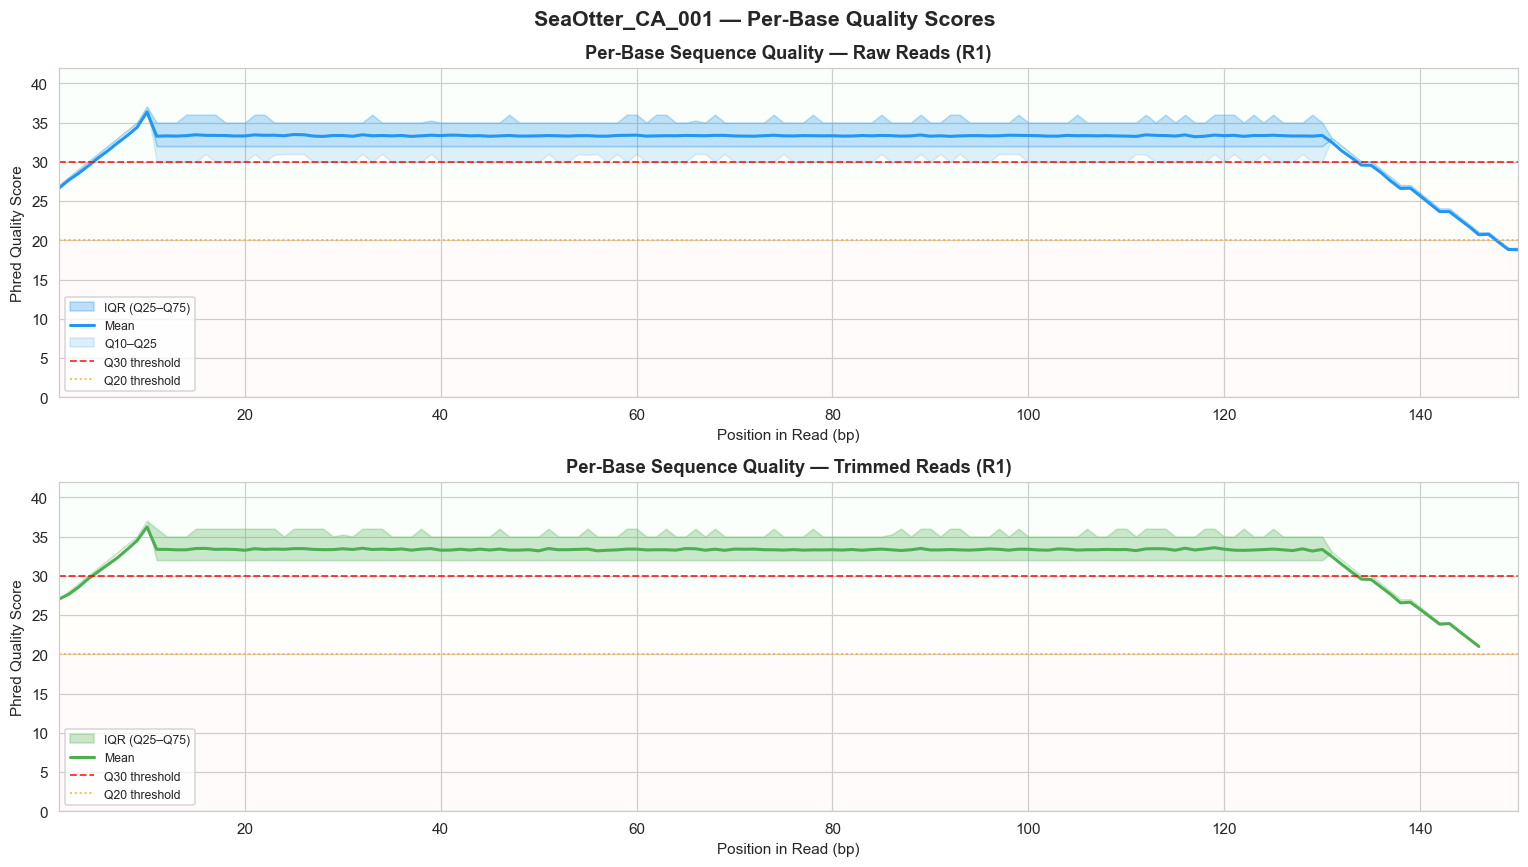

Viz 1 saved: viz1_quality_scores.png


In [13]:
# ───────────────────────────────────────────────────────────
# Viz 1 — Per-Base Quality Score Profile  (Raw vs Trimmed)
# ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)#AK Creates a figure with associated dimensions.
pos = np.arange(1, READ_LENGTH+1)#AK Creates an array of positions in the range of the length of the read.

for ax, q_mn, q_25, q_75, q_10, label, color in [
        (axes[0], QC['q1_mn'],  QC['q1_q25'], QC['q1_q75'], QC['q1_q10'],
         'Raw Reads (R1)', '#2196F3'),
        (axes[1], QC['tq1_mn'], QC['tq1_q25'],QC['tq1_q75'],None,
         'Trimmed Reads (R1)', '#4CAF50')]:#AK Retrieves information about quality scores for both raw and trimmed reads.

    ax.fill_between(pos[:len(q_25)], q_25, q_75, alpha=0.3, color=color,
                    label='IQR (Q25–Q75)')#AK Creates hte shaded portion in between the interquartile range
    ax.plot(pos[:len(q_mn)], q_mn, color=color, lw=2, label='Mean')#AK Draws the quality line.
    if q_10 is not None:#AK Checks if the q_10 value exists.
        ax.fill_between(pos[:len(q_10)], q_10, q_25, alpha=0.15,
                        color=color, label='Q10–Q25')#AK Creates a shaded region in between the 10 and 25 quality scores.

    ax.axhline(30, color='red',    lw=1.2, ls='--', alpha=0.8, label='Q30 threshold')#AK Draws a red dashed line for the 30 threshold.
    ax.axhline(20, color='orange', lw=1.2, ls=':', alpha=0.8, label='Q20 threshold')#AK Draws an orange line for the 20 threshold.
    ax.set_title(f'Per-Base Sequence Quality — {label}', fontweight='bold')#AK Sets the title.
    ax.set_xlabel('Position in Read (bp)')#AK Sets the x-axis label.
    ax.set_ylabel('Phred Quality Score')#AK Sets the y-axis label.
    ax.set_ylim(0, 42)#Sets the scale for y-axis.
    ax.set_xlim(1, READ_LENGTH)#AK Sets the scale for x-axis.
    ax.legend(loc='lower left', fontsize=8)#AK Creates a key for different elemnts in the figure.

    # Colour background zones
    for y0, y1, c in [(0,20,'#ffcccc'),(20,28,'#fff3cc'),(28,42,'#ccffcc')]:
        ax.axhspan(y0, y1, alpha=0.07, color=c)

plt.suptitle(f'{SAMPLE_NAME} — Per-Base Quality Scores', fontsize=14, fontweight='bold')#AK Creates a sub title.
plt.tight_layout()#Prevents anything from getting cutoff from plot.
plt.savefig('viz1_quality_scores.png', dpi=150, bbox_inches='tight')#AK Saves the figure to a png file.
plt.show()#AK Display the plot.
print('Viz 1 saved: viz1_quality_scores.png')#AK Print that the figure has been saved into a png file.


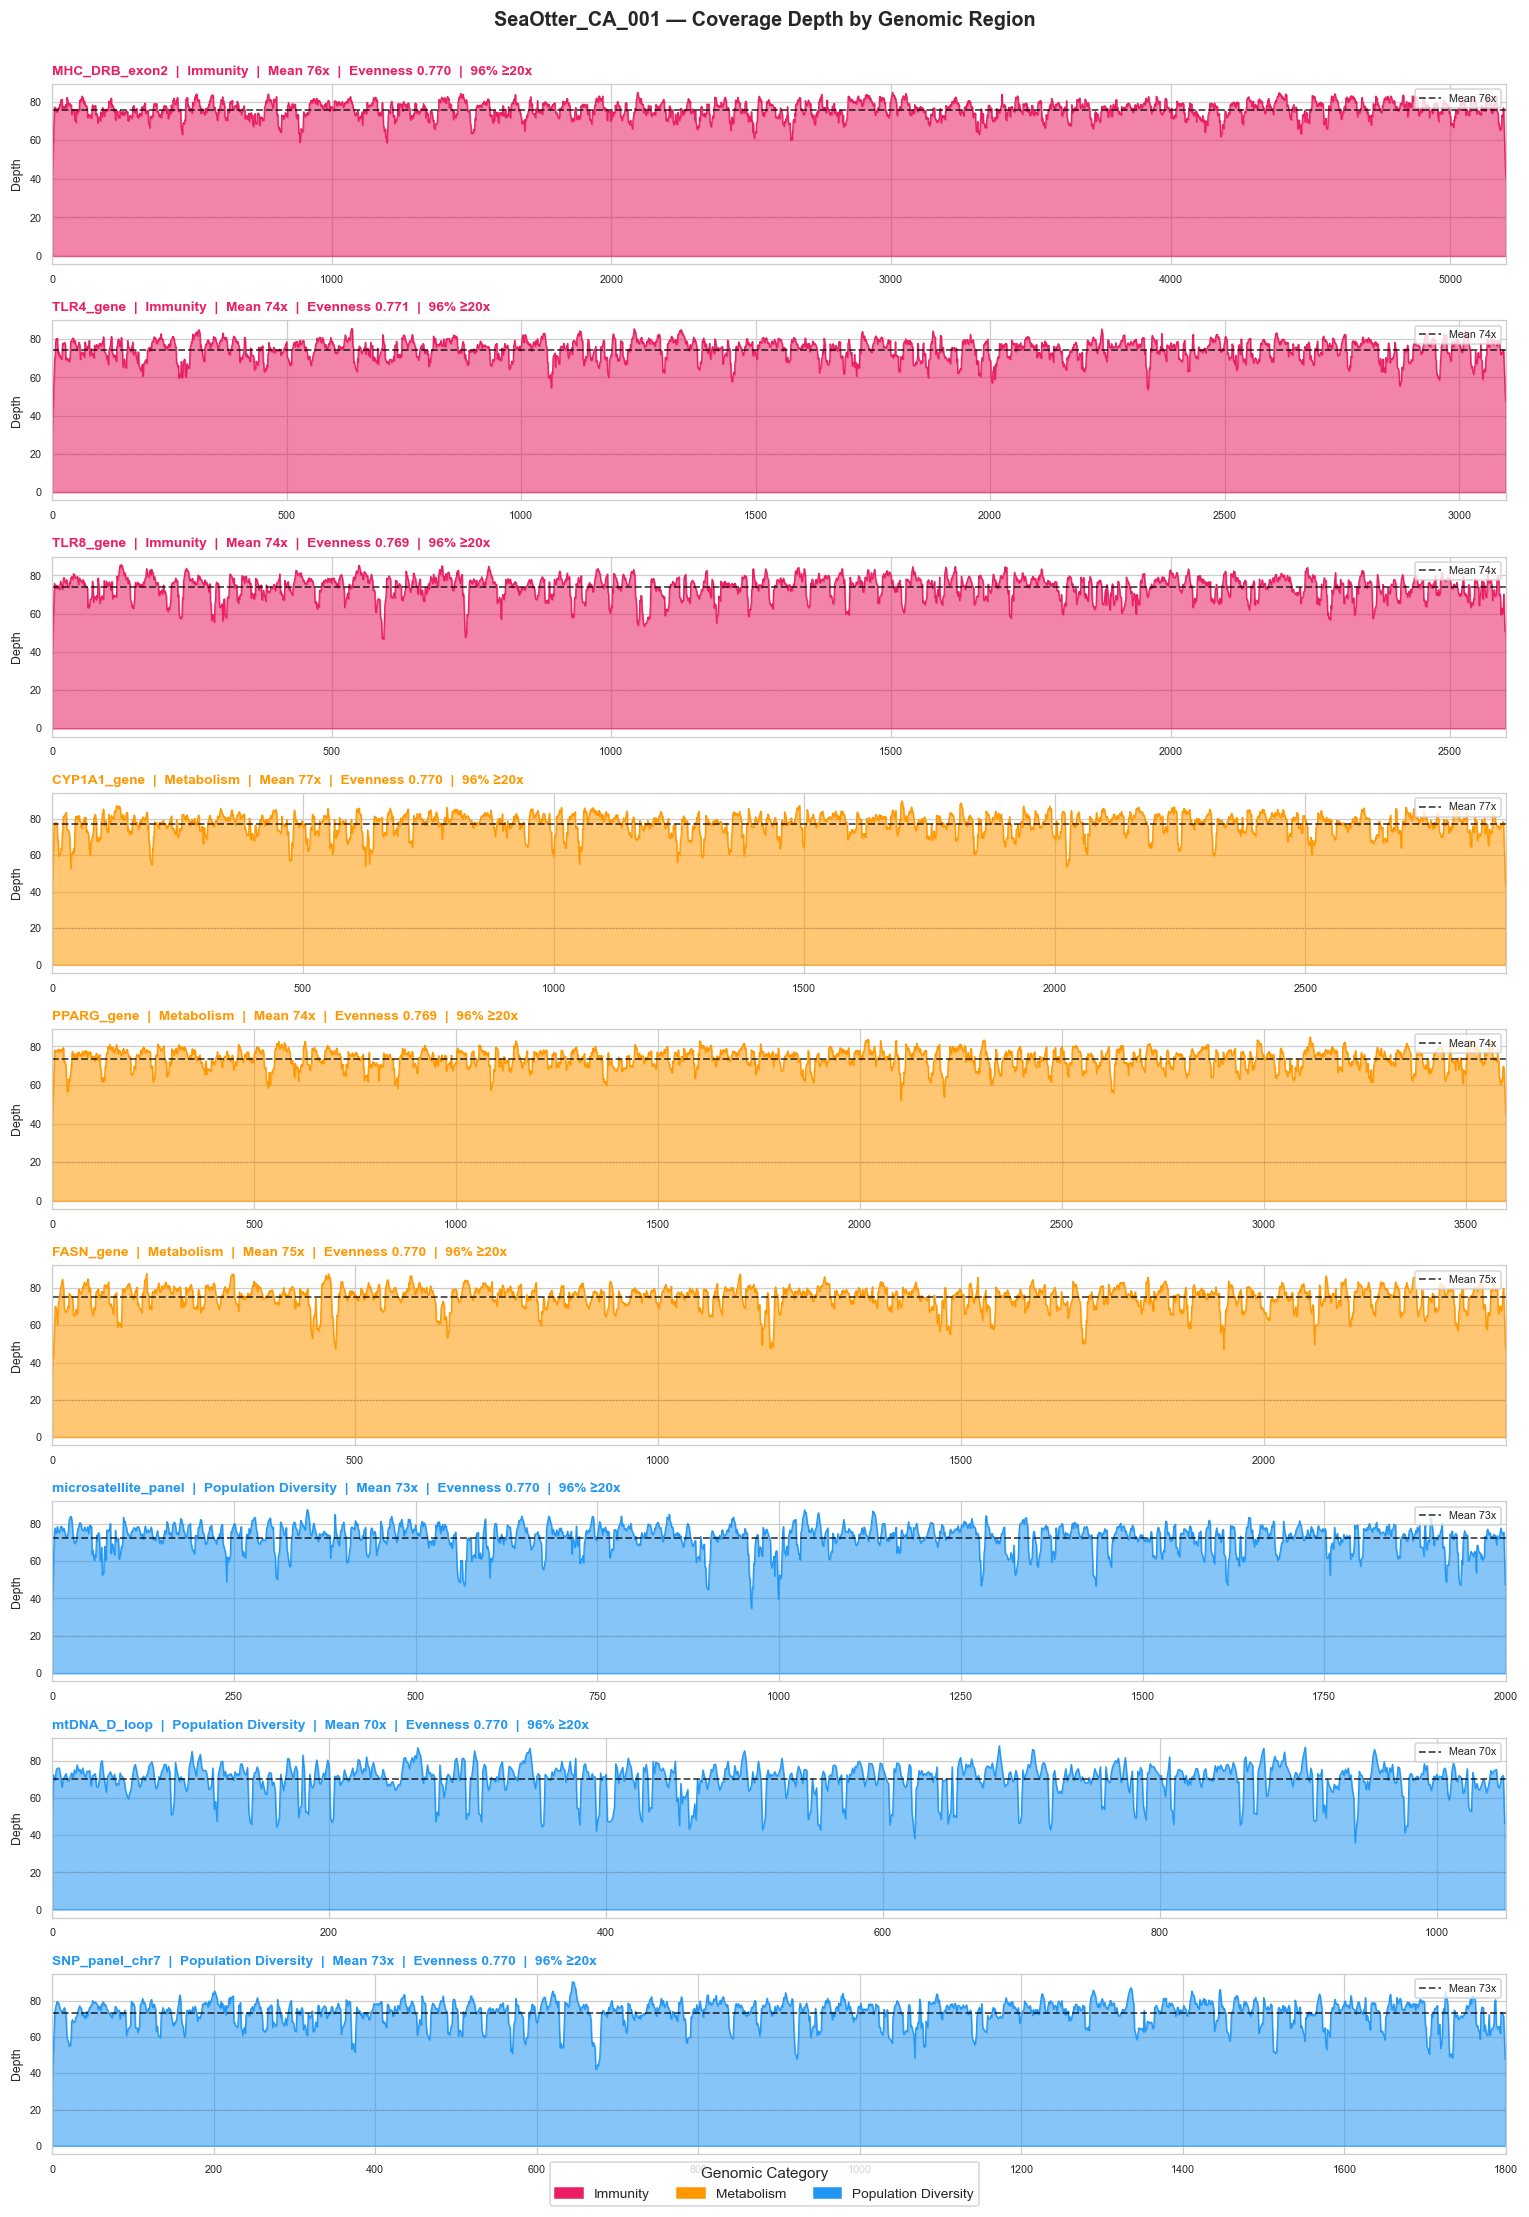

Viz 2 saved: viz2_coverage_depth.png


In [21]:
# ───────────────────────────────────────────────────────────
# Viz 2 — Coverage Depth Across Genomic Regions
# ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(len(reference_genome), 1,
                         figsize=(14, 2.2*len(reference_genome)),
                         sharex=False)#AK Creates the necessary plots.

cat_colors = {'Immunity':'#E91E63','Metabolism':'#FF9800','Population Diversity':'#2196F3'}#AK Creates a dictionary to assign colors to different category of genes.

for ax, (rname, cov) in zip(axes, coverage.items()):#AK Iterates through the sample and coverage information in the coverage dictionary.
    info   = REGIONS[rname]#AK Gets info about the region.
    col    = cat_colors[info['cat']]#AK Gets the corresponding color.
    xrange = np.arange(len(cov))#AK Creates an array of indices.

    # Smooth for display
    w     = max(1, len(cov)//300)#AK Calculates a window size for smoothing.
    cov_s = np.convolve(cov, np.ones(w)/w, mode='same')#AK Smoothes coverage.

    ax.fill_between(xrange, cov_s, alpha=0.55, color=col)#AK Shade in the region within the range under the curve.
    ax.plot(xrange, cov_s, color=col, lw=0.8)#AK Draws coverage line.
    ax.axhline(np.mean(cov), color='black', lw=1.2, ls='--', alpha=0.7,
               label=f'Mean {np.mean(cov):.0f}x')#AK Draw a dashed line representing the mean coverage.
    ax.axhline(20, color='grey', lw=0.8, ls=':', alpha=0.6)

    # Evenness annotation
    evenness = 1 - np.std(cov)/(np.mean(cov)+1e-9)#AK Calculates how uniformly distributed coverage is.
    ax.set_title(f'{rname}  |  {info["cat"]}  |  '
                 f'Mean {np.mean(cov):.0f}x  |  '
                 f'Evenness {evenness:.3f}  |  '
                 f'{np.mean(cov>=20)*100:.0f}% ≥20x',
                 fontsize=9, fontweight='bold', color=col, loc='left')#AK Sets title for each subplot: region, gene type, mean coverage, evenness, and percentage of bases < 20.
    ax.set_ylabel('Depth', fontsize=8)#AK Sets the label of the y-axis.
    ax.legend(fontsize=7, loc='upper right')#AK Creates a key for important aspects of plot.
    ax.set_xlim(0, len(cov))#AK Sets x-axis positions.
    ax.tick_params(labelsize=7)#AK Sets font of ticks on x-axis.

patches = [mpatches.Patch(color=c, label=k) for k,c in cat_colors.items()]
fig.legend(handles=patches, loc='lower center', ncol=3, fontsize=9,
           title='Genomic Category', bbox_to_anchor=(0.5, -0.01))#AK Shared legend for all subplots.
plt.suptitle(f'{SAMPLE_NAME} — Coverage Depth by Genomic Region',
             fontsize=13, fontweight='bold', y=1.001)#AK Creates title.
plt.tight_layout()#AK Makes sure no part of plot gets cut out.
plt.savefig('viz2_coverage_depth.png', dpi=150, bbox_inches='tight')#AK Saves the figure to a png file.
plt.show()#AK Displays the figure.
print('Viz 2 saved: viz2_coverage_depth.png')#AK Prints that the figure was saved to a png file.


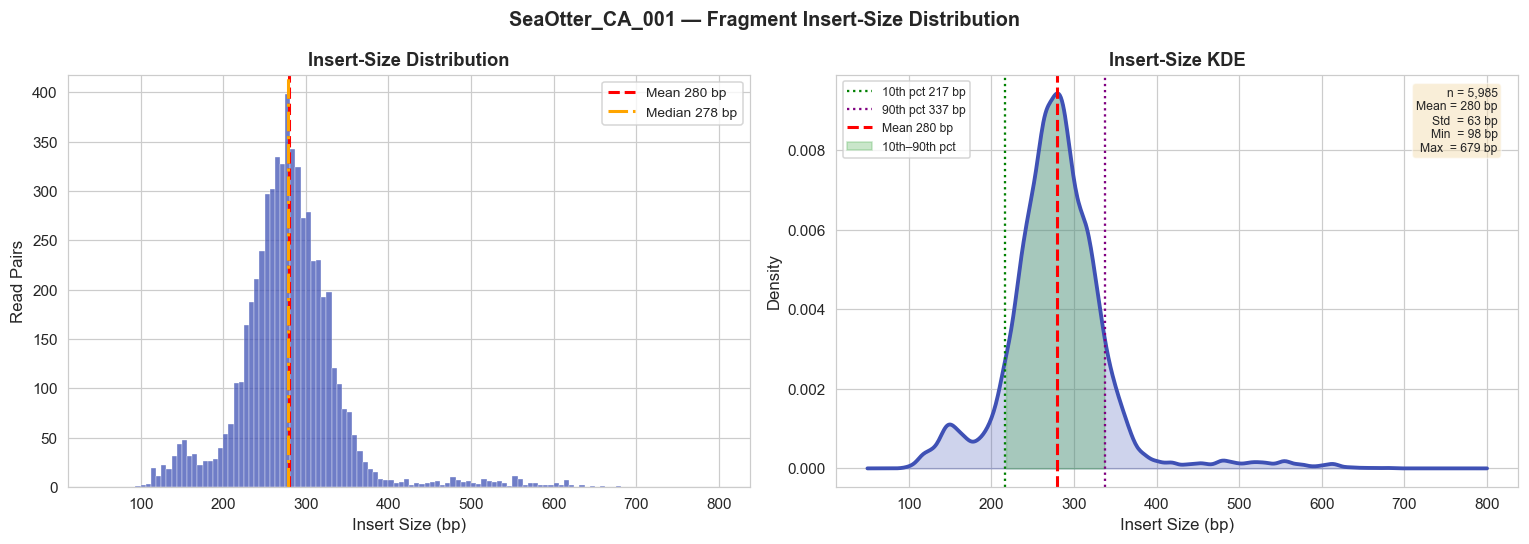

Viz 3 saved: viz3_insert_size.png


In [22]:
# ───────────────────────────────────────────────────────────
# Viz 3 — Insert-Size Distribution
# ───────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))#AK Creates figure with associated dimensions.

ins = QC['ins']#AK Retrievs information about insert-size from QC dictionary.

# Histogram
ax1.hist(ins, bins=120, range=(50, 800), color='#3F51B5', alpha=0.75,
         edgecolor='white', linewidth=0.3)#AK Creates a histogram to display distribution of insert sizes.
ax1.axvline(np.mean(ins),   color='red',    lw=2, ls='--',
            label=f'Mean {np.mean(ins):.0f} bp')#AK Creates a red vertical dashed line to represent the mean insert size.
ax1.axvline(np.median(ins), color='orange', lw=2, ls='-.',
            label=f'Median {np.median(ins):.0f} bp')#AK Creates an orange vertical dashed line to represent the median.
ax1.set_xlabel('Insert Size (bp)', fontsize=11)#AK Sets the the label of the x-axis.
ax1.set_ylabel('Read Pairs', fontsize=11)#AK Sets the label of the y-axis.
ax1.set_title('Insert-Size Distribution', fontsize=12, fontweight='bold')#AK Sets the title of the figure.
ax1.legend(fontsize=9)#AK Creates a key with the relevant information needed to understand the plot.

# KDE + percentile bands
from scipy.stats import gaussian_kde#AK Imports gaussian_kde library from scipy.stats
kde   = gaussian_kde(ins, bw_method=0.1)#AK Creates KDE object from insert sizes.
xs    = np.linspace(50, 800, 600)#AK Creates 600 evenly spaced values between 50 and 800
ys    = kde(xs)#AK Calculate the KDE at each x-value.
ax2.plot(xs, ys, color='#3F51B5', lw=2.5)#AK Plots the coordinates on the right plot.
ax2.fill_between(xs, ys, alpha=0.25, color='#3F51B5')#AK Shades the region between the coordinates.

p10, p90 = np.percentile(ins, 10), np.percentile(ins, 90)#AK Calculates the 10th and 90th percentile of insertion sizes.
ax2.axvline(p10, color='green',  ls=':', lw=1.5,
            label=f'10th pct {p10:.0f} bp')#AK Creates a green dashed line at 10th percentile.
ax2.axvline(p90, color='purple', ls=':', lw=1.5,
            label=f'90th pct {p90:.0f} bp')#AK Creates a purple dashed line at the 90th percentile.
ax2.axvline(np.mean(ins), color='red', ls='--', lw=2,
            label=f'Mean {np.mean(ins):.0f} bp')#AK Draws a red dashed line at the mean insertion.
ax2.fill_between(xs, ys,
                 where=(xs >= p10) & (xs <= p90),
                 alpha=0.30, color='#4CAF50', label='10th–90th pct')#AK Shades in the region between the 10th and 90th percentile.
ax2.set_xlabel('Insert Size (bp)', fontsize=11)#AK Creates a label for x-axis.
ax2.set_ylabel('Density', fontsize=11)#AK Creates a label for the y-axis.
ax2.set_title('Insert-Size KDE', fontsize=12, fontweight='bold')#AK Creates a title for the right figure.
ax2.legend(fontsize=8)#AK Creates a key with the relevant information about the right plot.

stats_txt = (f'n = {len(ins):,}\n'
             f'Mean = {np.mean(ins):.0f} bp\n'
             f'Std  = {np.std(ins):.0f} bp\n'
             f'Min  = {ins.min()} bp\n'
             f'Max  = {ins.max()} bp')#AK Stats about the insertion sizes.
ax2.text(0.97, 0.97, stats_txt, transform=ax2.transAxes,
         va='top', ha='right', fontsize=8,
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))#AK Creates a box on the upper right of the plot displaying this information.

plt.suptitle(f'{SAMPLE_NAME} — Fragment Insert-Size Distribution',
             fontsize=13, fontweight='bold')#AK Creates a title for the entire figure.
plt.tight_layout()#AK Makes sure that no part of the figure is cut off.
plt.savefig('viz3_insert_size.png', dpi=150, bbox_inches='tight')#AK Saves the figure to a png file.
plt.show()#AK Displays the figure.
print('Viz 3 saved: viz3_insert_size.png')#AK Prints that the figure was saved to a png file.


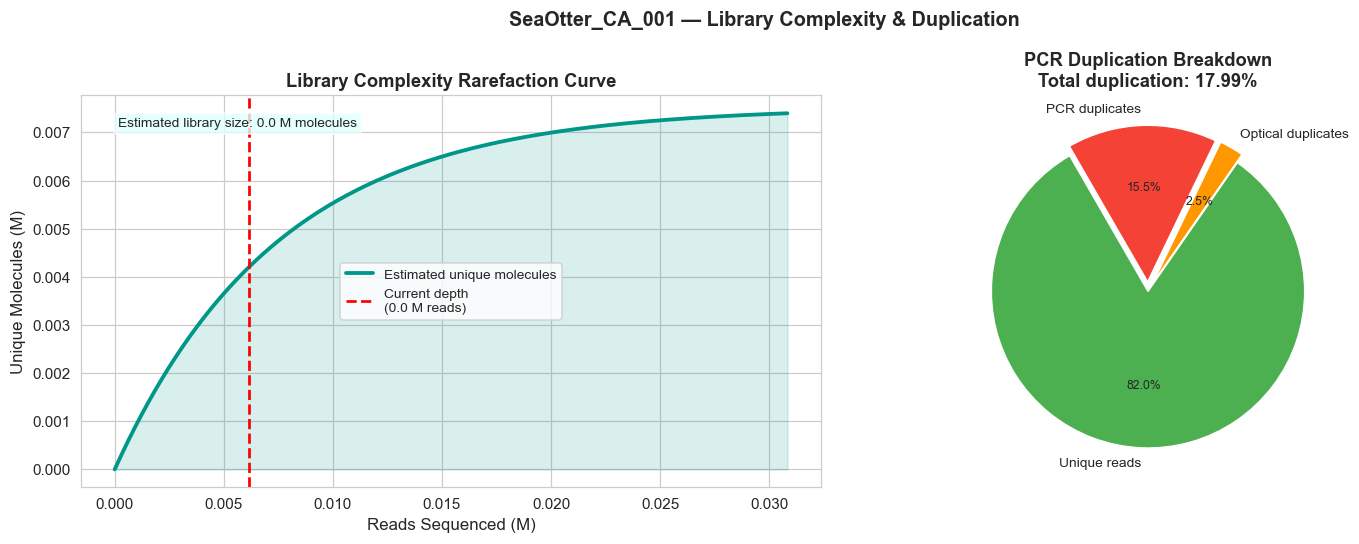

Viz 4 saved: viz4_library_complexity.png


In [16]:
# ───────────────────────────────────────────────────────────
# Viz 4 — Library Complexity & PCR Duplication
# ───────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))#AK Creates the figure with the associated dimensions.

# Rarefaction curve
x_r = QC['x_rare'] / 1e6#AK Changing the scale converting raw read counts into an easier to understand scale.
y_r = QC['y_rare'] / 1e6#AK Changing the scale converting raw read counts into an easier to understand scale.
ax1.plot(x_r, y_r, color='#009688', lw=2.5, label='Estimated unique molecules')#AK Plots the rarefaction curve.
ax1.axvline(n_mapped/1e6, color='red', ls='--', lw=1.8,
            label=f'Current depth\n({n_mapped/1e6:.1f} M reads)')#AK Plots a red dashed line representing the current depth.
ax1.fill_between(x_r, y_r, alpha=0.15, color='#009688')#AK Shades in the region between the curve.
ax1.set_xlabel('Reads Sequenced (M)', fontsize=11)#AK Sets the label for the x-axis to Reads Sequenced(M)
ax1.set_ylabel('Unique Molecules (M)', fontsize=11)#AK Sets the y-axis to the Unique Molecules.
ax1.set_title('Library Complexity Rarefaction Curve', fontsize=12, fontweight='bold')#AK Sets the title of the left plot.
ax1.legend(fontsize=9)#AK Creates a key with the relevant information to understand the left plot.
ax1.text(0.05, 0.92,
         f'Estimated library size: {QC["lib_size"]/1e6:.1f} M molecules',
         transform=ax1.transAxes, fontsize=9,
         bbox=dict(boxstyle='round', fc='lightcyan', alpha=0.8))#AK Creates text around the current depth red dashed line displaying estimated library size. The value shown doesn't make sense.

# Duplication breakdown pie
p = QC['picard']#AK Retrieves duplicate information.
dup_vals  = [n_mapped - QC['n_dups'], QC['n_opt_dups'],
             QC['n_dups'] - QC['n_opt_dups']]#AK Assigns the dup_vals to a list of the different categories of duplicates vs. unique reads.
dup_labs  = ['Unique reads', 'Optical duplicates', 'PCR duplicates']#AK Sets the labels.
dup_cols  = ['#4CAF50', '#FF9800', '#F44336']#AK Sets the colors.
explode   = [0, 0.06, 0.06]#AK Off centers the pie.
wedges, texts, autotexts = ax2.pie(dup_vals, labels=dup_labs,
                                    colors=dup_cols, explode=explode,
                                    autopct='%1.1f%%', startangle=120,
                                    textprops=dict(fontsize=9))#AK Creates the pie chart with the relevant parameters.
for at in autotexts:
    at.set_fontsize(8)#AK Sets the font of the labels.
ax2.set_title(f'PCR Duplication Breakdown\n'
              f'Total duplication: {p["PERCENT_DUPLICATION"]:.2f}%',
              fontsize=12, fontweight='bold')#AK Creates a title for the right pie chart.

plt.suptitle(f'{SAMPLE_NAME} — Library Complexity & Duplication',
             fontsize=13, fontweight='bold')#AK Creates a title for the entire figure.
plt.tight_layout()#AK Makes sure that none of the components of the figure is cut off.
plt.savefig('viz4_library_complexity.png', dpi=150, bbox_inches='tight')#AK Saves the figure to a png file.
plt.show()#AK Displays the figure.
print('Viz 4 saved: viz4_library_complexity.png')#AK Prints that the figure has been saved to a png file.


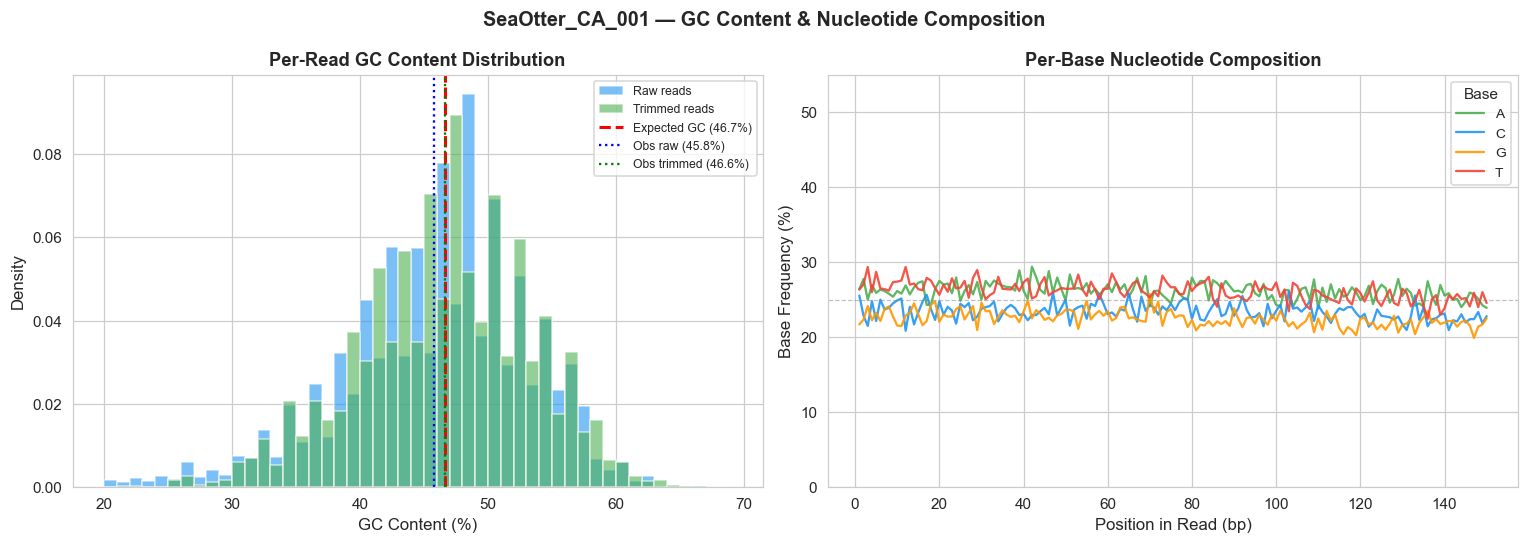

Viz 5 saved: viz5_gc_content.png


In [23]:
# ───────────────────────────────────────────────────────────
# Viz 5 — GC Content & Per-Base Nucleotide Composition
# ───────────────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))#AK Creates a plot with the associated dimensions.

gc_raw = QC['gc_per_read']#AK Gets the GC content from the raw reads.
gc_trm = QC['gc_qt']#AK Gets teh GC content data from the trimmed reads.
exp_gc = gc_frac(full_reference) * 100#AK Gets the percentage of GC content in the full reference genome.

# GC histogram
bins = np.arange(20, 70, 1)#AK Creates bins that represent the bars of the histogram.
ax1.hist(gc_raw, bins=bins, alpha=0.6, color='#2196F3', label='Raw reads',    density=True)#AK Creates a histogram for the GC content of the raw reads.
ax1.hist(gc_trm, bins=bins, alpha=0.6, color='#4CAF50', label='Trimmed reads', density=True)#AK Creates a histogram for the GC content of the trimmed reads.
ax1.axvline(exp_gc, color='red', lw=2, ls='--',
            label=f'Expected GC ({exp_gc:.1f}%)')#AK Draws a red dashed line for the expected GC content.
ax1.axvline(np.mean(gc_raw), color='blue', lw=1.5, ls=':',
            label=f'Obs raw ({np.mean(gc_raw):.1f}%)')#AK Draws a blue dashed line for the observed Mean GC content of raw reads.
ax1.axvline(np.mean(gc_trm), color='green', lw=1.5, ls=':',
            label=f'Obs trimmed ({np.mean(gc_trm):.1f}%)')#AK Draws a green dashed line for the GC content of the trimmed reads.
ax1.set_xlabel('GC Content (%)', fontsize=11)#AK Sets the label for x-axis.
ax1.set_ylabel('Density', fontsize=11)#AK Sets the label for the y-axis.
ax1.set_title('Per-Read GC Content Distribution', fontsize=12, fontweight='bold')#AK Sets the title of the left figure.
ax1.legend(fontsize=8)#AK Creates a key for the left plot with the relevant information needed to understand the plot.

# Per-base nucleotide composition from raw reads
N_BS  = min(2000, len(reads_r1))#AK Caps samples at 2000.
b_idx = random.sample(range(len(reads_r1)), N_BS)#AK Randomly selects N_BS number of read indices.
bases_mat = {'A': np.zeros(READ_LENGTH), 'C': np.zeros(READ_LENGTH),
             'G': np.zeros(READ_LENGTH), 'T': np.zeros(READ_LENGTH)}#AK Creates a dictionary with the bases as keys and an empty array as the value for each base.
for idx in b_idx:#AK Iterates through the randomly selected read indices.
    seq = reads_r1[idx][1]#AK Gets the sequence string.
    for pos_i, base in enumerate(seq):#AK Iterates through the index and each character of the sequence.
        if base in bases_mat:#AK If the base is in the bases_mat dictionary
            bases_mat[base][pos_i] += 1#AK Update the position in the array for that value by adding 1.

total = sum(bases_mat.values())#AK Get the total number of bases per position.
pos_a = np.arange(1, READ_LENGTH+1)#AK Creates x-axis positions.
base_colors = {'A':'#4CAF50','C':'#2196F3','G':'#FF9800','T':'#F44336'}#AK Creates a dictionary to set colors for each base.
for base, counts in bases_mat.items():#AK Iterates through the bases and their counts
    pct = counts / N_BS * 100#AK Calculates the percentage that the base appears.
    ax2.plot(pos_a, pct, label=base, color=base_colors[base], lw=1.5, alpha=0.9)#AK Draws a line for the corresponding nucleotide.

ax2.axhline(25, color='grey', lw=0.8, ls='--', alpha=0.5)#AK Creates a grey dashed line at 25%.
ax2.set_xlabel('Position in Read (bp)', fontsize=11)#AK Sets the label for the x-axis.
ax2.set_ylabel('Base Frequency (%)', fontsize=11)#AK Sets the label of the y-axis.
ax2.set_title('Per-Base Nucleotide Composition', fontsize=12, fontweight='bold')#AK Sets the title of the right figure.
ax2.legend(title='Base', fontsize=9)#AK Creates a key with the relevant information to understand the plot.
ax2.set_ylim(0, 55)#AK Sets the values for the y-axis.

plt.suptitle(f'{SAMPLE_NAME} — GC Content & Nucleotide Composition',
             fontsize=13, fontweight='bold')#AK Sets the name of the entire figure.
plt.tight_layout()#AK Makes sure that none of the content of the plots get cutoff in the figure panel.
plt.savefig('viz5_gc_content.png', dpi=150, bbox_inches='tight')#AK Saves the figure to a png file.
plt.show()#AK Displays the figure.
print('Viz 5 saved: viz5_gc_content.png')#AK Prints that the Figure has been saved in a png file.


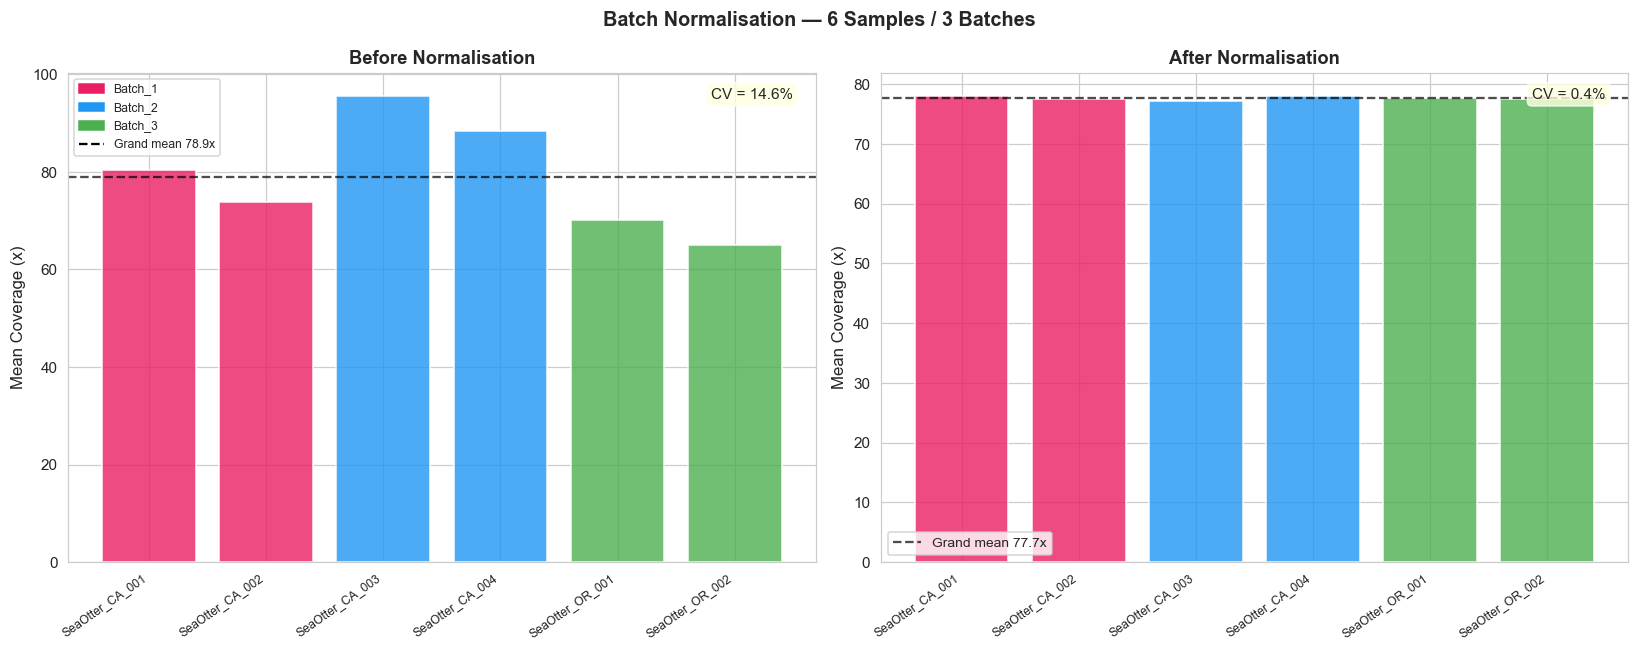

Viz 6 saved: viz6_batch_normalisation.png


In [24]:
# ───────────────────────────────────────────────────────────
# Viz 6 — Batch Normalisation: Before vs After
# ───────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))#AK Creates a figure with the associated dimensions.

batch_palette = {'Batch_1':'#E91E63','Batch_2':'#2196F3','Batch_3':'#4CAF50'}#AK Creates a dictionary with the color scheme for each batch sample.

for ax, covs, title in [(axes[0], QC['raw_covs'],  'Before Normalisation'),
                        (axes[1], QC['norm_covs'], 'After Normalisation')]:#AK Iterates through the figures and the QC information about raw and normalized coverages before and after normalization.
    plot_data  = []#A list that will contain mean coverage information for each sample from each batch.
    for samp, region_cov in covs.items():#AK Iterates through the keys and values of the covs dictionary.
        batch  = QC['samples_meta'][samp]['batch']#AK Looks up which batch the sample belongs to.
        mean_c = np.mean([np.mean(c) for c in region_cov.values()])#AK Calculates the mean coverage for that sample.
        plot_data.append({'Sample': samp, 'Batch': batch, 'Mean Coverage': mean_c})#AK Appends a dictionary with sample, batch, and mean coverage data to the plot_data list.
    df_p = pd.DataFrame(plot_data)#AK Create a pandas dataframe from plot_data.

    x_pos = np.arange(len(df_p))#AK Create the x-axis positions.
    colors= [batch_palette[b] for b in df_p['Batch']]#AK Set the colors to the color from the batch_palette dictionary for each sample.
    bars  = ax.bar(x_pos, df_p['Mean Coverage'], color=colors, alpha=0.8,
                   edgecolor='white', linewidth=1.2)#AK Create a bar plot for each sample with the length being the mean coverage.
    ax.set_xticks(x_pos)#AK Set ticks on the x-axis.
    ax.set_xticklabels(df_p['Sample'], rotation=35, ha='right', fontsize=8)#AK Add the sample names to each tick on the x-axis.
    ax.set_ylabel('Mean Coverage (x)', fontsize=11)#AK Set the label of the y-axis.
    ax.set_title(title, fontsize=12, fontweight='bold')#AK Set the title of the entire figure.
    ax.axhline(df_p['Mean Coverage'].mean(), color='black',
               lw=1.5, ls='--', alpha=0.7,
               label=f'Grand mean {df_p["Mean Coverage"].mean():.1f}x')#AK Creat a black dashed line that indicates the mean coverage of all samples from all batches.
    ax.legend(fontsize=9)#AK Create a key with fontsize of 9 that contains the relevant information to understand the plot better.

    cv_val = df_p['Mean Coverage'].std() / df_p['Mean Coverage'].mean() * 100#AK Calculates the coefficient of variation.
    ax.text(0.97, 0.97, f'CV = {cv_val:.1f}%', transform=ax.transAxes,
            ha='right', va='top', fontsize=10,
            bbox=dict(boxstyle='round', fc='lightyellow', alpha=0.8))#AK Display the CV on the plot in a small box.

    # Add batch legend patches on first subplot
    if ax is axes[0]:#AK Checks if the left plot.
        handles = [mpatches.Patch(color=c, label=b)
                   for b,c in batch_palette.items()]#AK Creates a colored rectangle for each batch.
        ax.legend(handles=handles + [
            plt.Line2D([0],[0], color='black', ls='--', lw=1.5,
                       label=f'Grand mean {df_p["Mean Coverage"].mean():.1f}x')],
            fontsize=8)#AK Creates a key containing the batch numbers and their corresponding colors.

plt.suptitle(f'Batch Normalisation — {len(QC["samples_meta"])} Samples / 3 Batches',
             fontsize=13, fontweight='bold')#AK Creates a title for the entire figure.
plt.tight_layout()#AK Makes sure that none of the content of the figure gets cut off.
plt.savefig('viz6_batch_normalisation.png', dpi=150, bbox_inches='tight')#AK Saves the figure to a png file.
plt.show()#AK Display the figure.
print('Viz 6 saved: viz6_batch_normalisation.png')#AK Print that the figure has been saved to a png file.


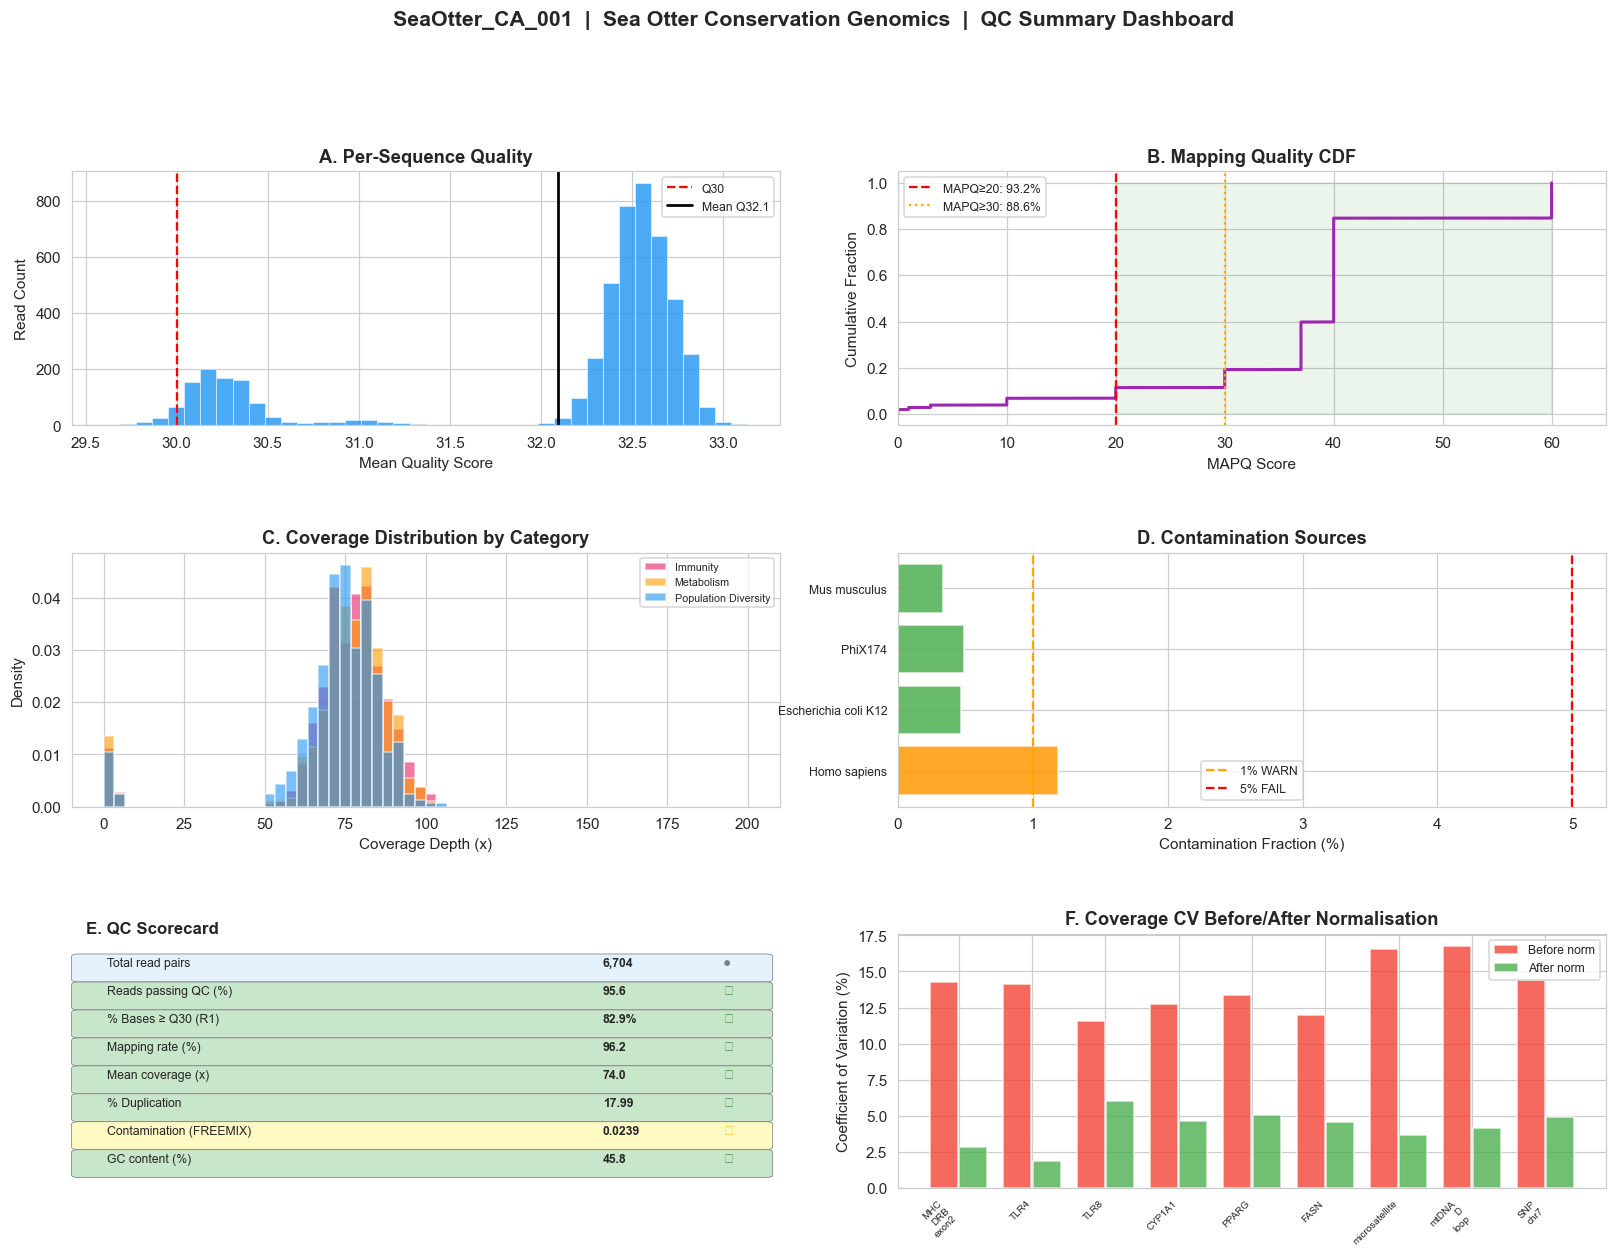

Viz 7 saved: viz7_qc_dashboard.png


In [25]:
# ───────────────────────────────────────────────────────────
# Viz 7 — Comprehensive QC Summary Dashboard
# ───────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))#AK Creates a figure with the associated dimensions.
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.50, wspace=0.40)#AK Divides the figure like a grid to account for various subplots that are going to be created.

# ── Panel A: Per-sequence quality histogram ─────────────────
ax_a = fig.add_subplot(gs[0, 0:2])#AK Creates a subplot with the associated dimensions.
ax_a.hist(QC['mean_q_per_read'], bins=40, color='#2196F3',
          alpha=0.8, edgecolor='white', lw=0.4)#AK Creates a histogram with the mean quality scores per read.
ax_a.axvline(30, color='red',    ls='--', lw=1.5, label='Q30')#AK Draws a red dashed line to represent a quality score of 30.
ax_a.axvline(np.mean(QC['mean_q_per_read']), color='black',
             ls='-', lw=1.8, label=f'Mean Q{np.mean(QC["mean_q_per_read"]):.1f}')#AK Draws a black solid line to indicate the meam quality score throughout the reads.
ax_a.set_xlabel('Mean Quality Score'); ax_a.set_ylabel('Read Count')#AK Set the label of the x-axis.
ax_a.set_title('A. Per-Sequence Quality', fontweight='bold')#AK Sets the title of the subplot ax_a.
ax_a.legend(fontsize=8)#AK Creates a key containing the relevant information needed to understand the subplot.

# ── Panel B: Mapping quality CDF ────────────────────────────
ax_b = fig.add_subplot(gs[0, 2:4])#AK Creates a new subplot with the associated dimensions.
mapq_sorted = np.sort(QC['mapq'])#AK Sorts the mapping quality scores from the QC dictionary.
cdf = np.arange(1, len(mapq_sorted)+1) / len(mapq_sorted)#AK Builds the cumulative distribution.
ax_b.plot(mapq_sorted, cdf, color='#9C27B0', lw=2)#AK Plots the distribution.
ax_b.axvline(20, color='red', ls='--', lw=1.5,
             label=f'MAPQ≥20: {np.mean(QC["mapq"]>=20)*100:.1f}%')#AK Draws a red dashed line that marks the plot at a mapping quality of 20.
ax_b.axvline(30, color='orange', ls=':', lw=1.5,
             label=f'MAPQ≥30: {np.mean(QC["mapq"]>=30)*100:.1f}%')#AK Draws an orange dashed line that marks the plot at a mappting quality of 30.
ax_b.fill_betweenx([0,1], 20, max(mapq_sorted),
                   alpha=0.08, color='green')#AK Shades the plot from 20 to the maximum mapping quality score.
ax_b.set_xlabel('MAPQ Score'); ax_b.set_ylabel('Cumulative Fraction')#AK Sets the label for the x-axis and the label for the y-axis.
ax_b.set_title('B. Mapping Quality CDF', fontweight='bold')#AK Set the title of the ax_b plot.
ax_b.legend(fontsize=8); ax_b.set_xlim(0, 65)#AK Creates a key with the relevant information needed to understand the ax_b plot and set the x-axis positions.

# ── Panel C: Coverage distribution by category ──────────────
ax_c = fig.add_subplot(gs[1, 0:2])#AK Creates another sublplot.
cat_cov = defaultdict(list)#AK Creates a dictionary where the value is a list by default.
for rname, cov in QC['cov'].items():#AK Iterates through each region and its coverage array in the QC dictionary.
    cat = REGIONS[rname]['cat']#AK Finds what category the sample belongs to.
    cat_cov[cat].extend(cov[::10].tolist())   # subsample
cat_colors = {'Immunity':'#E91E63','Metabolism':'#FF9800','Population Diversity':'#2196F3'}#AK Creates a dictionary with the category and their corresponding color.
for i,(cat,vals) in enumerate(cat_cov.items()):#AK Iterates through the index and a tuple of the region and coverage array.
    ax_c.hist(vals, bins=60, range=(0,200), alpha=0.6,
              color=cat_colors[cat], label=cat, density=True)#Creates a histogram for each category.
ax_c.set_xlabel('Coverage Depth (x)'); ax_c.set_ylabel('Density')#AK Sets the label for the x and y axis.
ax_c.set_title('C. Coverage Distribution by Category', fontweight='bold')#AK Sets the title of the ax_c plot.
ax_c.legend(fontsize=7)#AK Creates a key with the relevant information needed to understand the plot.

# ── Panel D: Contamination bar chart ────────────────────────
ax_d = fig.add_subplot(gs[1, 2:4])#AK Creates a new subplot.
contam = QC['contam_df']#AK Retrieves information about contaminated reads from the QC dictionary.
non_target = contam[contam['Source'] != 'Enhydra lutris (target)']
colors_d = ['#F44336' if s=='FAIL' else '#FF9800' if s=='WARN' else '#4CAF50'
            for s in non_target['Status']]#AK A list of the colors associated with each status.
bars = ax_d.barh(range(len(non_target)), non_target['Fraction (%)'],
                 color=colors_d, alpha=0.85, edgecolor='white')#AK Creates a barplot with the a bar for each contamination source.
ax_d.set_yticks(range(len(non_target)))#AK Sets the ticks for the y-axis.
ax_d.set_yticklabels([s.split('(')[0].strip() for s in non_target['Source']],
                     fontsize=8)#AK Sets the labels for the y-ticks.
ax_d.axvline(1.0, color='orange', ls='--', lw=1.5, label='1% WARN')#AK Draws an orange dashed line for 1% Warn.
ax_d.axvline(5.0, color='red',    ls='--', lw=1.5, label='5% FAIL')#AK Draws a dashed red line for 5% Fail.
ax_d.set_xlabel('Contamination Fraction (%)');#AK Sets the label for the x-axis.
ax_d.set_title('D. Contamination Sources', fontweight='bold')#AK Sets the title for the subplot.
ax_d.legend(fontsize=8)#AK Creates a key with the relevant information needed to understand the plot.

# ── Panel E: QC metrics scorecard ──────────────────────────
ax_e = fig.add_subplot(gs[2, 0:2])#AK Adds another subplot.
ax_e.axis('off')#AK Turns off visual elements of that subplot's axes.
scorecard = [
    ('Total read pairs',      f'{TOTAL_READS:,}',                    'neutral'),
    ('Reads passing QC (%)',  f'{qt["passing"]/TOTAL_READS*100:.1f}','pass' if qt["passing"]/TOTAL_READS > 0.90 else 'warn'),
    ('% Bases ≥ Q30 (R1)',    qc_raw['% bases ≥ Q30 (R1)'] + '%',   'pass' if float(qc_raw['% bases ≥ Q30 (R1)']) >= 80 else 'warn'),
    ('Mapping rate (%)',       f'{MAP_RATE*100:.1f}',                 'pass' if MAP_RATE >= 0.90 else 'warn'),
    ('Mean coverage (x)',      f'{np.mean([np.mean(c) for c in QC["cov"].values()]):.1f}', 'pass'),
    ('% Duplication',          f'{QC["picard"]["PERCENT_DUPLICATION"]:.2f}',   'pass' if QC["picard"]["PERCENT_DUPLICATION"] < 20 else 'warn'),
    ('Contamination (FREEMIX)',f'{QC["freemix"]:.4f}',               'pass' if QC["freemix"] < 0.02 else 'warn'),
    ('GC content (%)',         qc_raw['Mean GC (%)'],                 'pass'),
]#AK Contains summary statistics about the Quality control analysis.
col_map = {'pass':'#c8e6c9','warn':'#fff9c4','fail':'#ffcdd2','neutral':'#e3f2fd'}#AK Creates a dictionary with the colors associated with their status.
y_sc = 0.97#AK Starting y-position.
ax_e.text(0.02, y_sc+0.03, 'E. QC Scorecard', transform=ax_e.transAxes,
          fontsize=11, fontweight='bold')#AK PLaces text element.
for metric, value, status in scorecard:#AK Iterates through the scorecard list.
    y_sc -= 0.11#AK Moves the position down.
    ax_e.add_patch(mpatches.FancyBboxPatch(
        (0.01, y_sc-0.04), 0.97, 0.09,
        boxstyle='round,pad=0.01',
        facecolor=col_map[status], edgecolor='grey', linewidth=0.5,
        transform=ax_e.transAxes, clip_on=False))#AK Draws a colored rectangle for each metric.
    ax_e.text(0.05, y_sc+0.01, metric, transform=ax_e.transAxes, fontsize=8)#AK Adds the metric to the row formatted on the left side.
    ax_e.text(0.75, y_sc+0.01, value,  transform=ax_e.transAxes, fontsize=8,
              fontweight='bold', ha='left')#AK Adds the metric value to the right side of the row.
    sym = '✓' if status=='pass' else ('⚠' if status=='warn' else '●')#AK Assigns symbols to the different statuses.
    ax_e.text(0.92, y_sc+0.01, sym, transform=ax_e.transAxes, fontsize=9,
              color='green' if status=='pass' else ('orange' if status=='warn' else 'grey'))#AK Adds the symbol and sets the corresponding color to the status.

# ── Panel F: CV before/after normalisation ─────────────────
ax_f = fig.add_subplot(gs[2, 2:4])#AK Adds the last subplot.
regions_short = [r.replace('_gene','').replace('_panel','').replace('_','\n')
                 for r in reference_genome.keys()]#AK Cleans up region names for display.
cv_b = list(QC['cv_before'].values())#AK Retrieves the CV percentages before normalization.
cv_a = list(QC['cv_after'].values())#AK Retrieves the CV percentages after normalization.
x_cv = np.arange(len(cv_b))#AK Create the x-axis positions.
ax_f.bar(x_cv - 0.2, cv_b, 0.38, label='Before norm', color='#F44336', alpha=0.8)#AK Draw a bar for the before normalization with a certain color.
ax_f.bar(x_cv + 0.2, cv_a, 0.38, label='After norm',  color='#4CAF50', alpha=0.8)#AK Draw a bar for the after normalization with a different color.
ax_f.set_xticks(x_cv)#AK Set the ticks on the x-axis.
ax_f.set_xticklabels(regions_short, fontsize=6.5, rotation=45, ha='right')#AK Set the labels for the ticks on the x-axis.
ax_f.set_ylabel('Coefficient of Variation (%)')#AK Set the label for the y-axis.
ax_f.set_title('F. Coverage CV Before/After Normalisation', fontweight='bold')#AK Set the title for the subplot.
ax_f.legend(fontsize=8)#AK Create a key with the required information to understand ax_f.

plt.suptitle(f'{SAMPLE_NAME}  |  {PROJECT}  |  QC Summary Dashboard',
             fontsize=14, fontweight='bold', y=1.002)#AK Creates the title for the entire figure.
plt.savefig('viz7_qc_dashboard.png', dpi=150, bbox_inches='tight')#AK Saves the figure to a png file.
plt.show()#AK Display the figure.
print('Viz 7 saved: viz7_qc_dashboard.png')#AK Print that the figure has been saved to a png file.


---
## Section 5 — Final QC Report


In [26]:
# ═══════════════════════════════════════════════════════════
# Final QC Report Generator
# ═══════════════════════════════════════════════════════════

def pass_fail(val, lo=None, hi=None, invert=False):#AK A function that returns PASS or FAIL given a certain threshold.
    if lo is not None and val < lo: return 'FAIL'#AK Checks if the lo value exists and compares to the input val, if val<lo, then FAIL.
    if hi is not None and val > hi: return 'FAIL'#AK Checks if the hi value exists and compares to the input val, if hi<val, then FAIL.
    return 'PASS'#AK Else PASS.

# ── Gather summary statistics ──────────────────────────────
q30_pct   = float(qc_raw['% bases ≥ Q30 (R1)'])#AK Gets the percentage of bases that have a quality score greater than 30.
map_pct   = MAP_RATE * 100#AK Calculates the mapping rate as a percentage.
dup_pct   = QC['picard']['PERCENT_DUPLICATION']#AK Calculates the Duplicates rate.
mean_cov  = np.mean([np.mean(c) for c in QC['cov'].values()])#AK Calculates the overall mean coverage across the 10 regions.
contam_pct= QC['freemix'] * 100#AK Freemix contamination score.
pass_pct  = qt['passing'] / TOTAL_READS * 100#AK Percentage of reads that passed trimming.
cv_after_mean = np.mean(list(QC['cv_after'].values()))#AK Average CV after normalization.

checks = {
    '% Bases ≥ Q30'          : (q30_pct,   '>= 80',  q30_pct  >= 80),
    'Mapping rate (%)'        : (map_pct,   '>= 90',  map_pct  >= 90),
    'Mean coverage (x)'       : (mean_cov,  '>= 30',  mean_cov >= 30),
    '% Duplication'           : (dup_pct,   '<= 25',  dup_pct  <= 25),
    'Contamination FREEMIX'   : (contam_pct,'<= 2',   contam_pct <= 2),
    'Reads passing QC (%)'    : (pass_pct,  '>= 90',  pass_pct >= 90),
    'CV post-normalisation (%)': (cv_after_mean, '<= 15', cv_after_mean <= 15),
}#AK A dictionary with a series of checks.

n_pass = sum(1 for _,_,p in checks.values() if p)#AK Counting number of passes.
n_warn = sum(1 for _,_,p in checks.values() if not p)#AK Checking number of fails.
overall = 'HIGH QUALITY — PASS' if n_warn == 0 else (
          'ACCEPTABLE — CONDITIONAL PASS' if n_warn <= 2 else
          'LOW QUALITY — FAIL')#AK Comes to a consensus if the data passed the Quality Control Analysis.
overall_color = 'green' if n_warn == 0 else ('orange' if n_warn <= 2 else 'red')#AK Set the color based on status.

# ── Print report ───────────────────────────────────────────
border = '=' * 70#AK Formatting.
thin   = '-' * 70#AK Formatting.

print(border)#AK Formatting
print(f'  FINAL NGS QUALITY CONTROL REPORT')#AK Print title.
print(f'  Sea Otter Conservation Genomics — {SPECIES}')#AK Print another title.
print(border)#AK Formatting.
print(f'  Sample ID      : {SAMPLE_NAME}')#AK Print sample ID.
print(f'  Project        : {PROJECT}')#AK Print Project.
print(f'  Analysis Date  : {ANALYSIS_DATE}')#AK Print date of analysis.
print(f'  Pipeline       : Illumina PE150 WGS QC v1.0')#AK Print the data used.
print(thin)#AK Formatting.

print()#AK Print empty line.
print('  ┌─ 1. READ QUALITY & PREPROCESSING ─────────────────────────┐')#AK Formatting.
print(f'  │  Total read pairs          : {TOTAL_READS:>12,}                 │')#AK Read-pairs.
print(f'  │  Reads passing QC          : {qt["passing"]:>12,}  ({pass_pct:.1f}%)         │')#AK Reads passing QC.
print(f'  │  Mean quality (R1)         : Q{np.mean(QC["q1_mn"]):<11.1f}                 │')#AK Mean quality.
print(f'  │  Bases ≥ Q30 (R1)          : {q30_pct:>11.1f}%                 │')#AK Bases >= 30
print(f'  │  Mean GC content           : {float(qc_raw["Mean GC (%)"]):>11.1f}%                 │')#AK Mean GC content.
print(f'  │  Adapter trimmed           : {atrim["trimmed"]:>12,}  ({atrim["trimmed"]/N_READS*100:.1f}%)         │')#AK Adapter trimmed reads.
print(f'  │  Quality-trimmed (filtered): {qt["filtered"]:>12,}                 │')#AK Filtered quality trimmed reads.
print('  └────────────────────────────────────────────────────────────┘')#AK Formatting.

print()#AK Print empty line.
print('  ┌─ 2. ALIGNMENT METRICS ─────────────────────────────────────┐')#AK Formatting.
print(f'  │  Mapping rate              : {map_pct:>11.1f}%                 │')#AK Mapping rate.
print(f'  │  Properly paired           : {PAIR_RATE*100:>11.1f}%                 │')#AK Properly paired reads.
print(f'  │  Mean insert size          : {np.mean(QC["ins"]):>11.0f} bp                │')#AK Mean insert size.
print(f'  │  Median MAPQ               : {int(np.median(QC["mapq"])):>12}                 │')#AK Median Mapping Quality Score.
print(f'  │  MAPQ ≥ 20                 : {np.mean(QC["mapq"]>=20)*100:>11.1f}%                 │')#AK Percentage of scores >= 20.
print(f'  │  Overall mean coverage     : {mean_cov:>11.1f}x                 │')#AK Overall mean coverage.
print('  └────────────────────────────────────────────────────────────┘')#AK Formatting.

print()#AK Print empty line.
print('  ┌─ 3. DUPLICATION & LIBRARY COMPLEXITY ──────────────────────┐')#AK Formatting.
print(f'  │  PCR duplicate rate        : {dup_pct:>11.3f}%                 │')#AK PCR duplication rate.
print(f'  │  Optical duplicates        : {QC["n_opt_dups"]:>12,}                 │')#AK Optical duplicates.
print(f'  │  Estimated library size    : {QC["lib_size"]:>12,}                 │')#AK Estimated library size.
print('  └────────────────────────────────────────────────────────────┘')#AK Formatting.

print()#AK Print empty line.
print('  ┌─ 4. CONTAMINATION ─────────────────────────────────────────┐')#AK Formatting.
print(f'  │  FREEMIX estimate          : {contam_pct:>11.4f}%                 │')#AK FREEMIX estimate
print(f'  │  Human contamination       : {QC["contam_df"].iloc[0]["Fraction (%)"]:>11.3f}%                 │')#AK Fraction of human contaminated reads.
print(f'  │  Bacterial contamination   : {QC["contam_df"].iloc[1]["Fraction (%)"]:>11.3f}%                 │')#AK Fraction of bacterial contaminated reads.
print('  └────────────────────────────────────────────────────────────┘')#AK Formatting.

print()#AK Print empty line.
print('  ┌─ 5. BATCH NORMALISATION ───────────────────────────────────┐')#AK Formatting.
print(f'  │  Samples normalised        : {len(QC["samples_meta"]):>12}                 │')#AK Number of samples normalized.
print(f'  │  Mean CV before norm       : {np.mean(list(QC["cv_before"].values())):>11.1f}%                 │')#AK Mean CV before normalization.
print(f'  │  Mean CV after norm        : {cv_after_mean:>11.1f}%                 │')#AK Mean CV after normalization.
print(f'  │  CV reduction              : {(np.mean(list(QC["cv_before"].values()))-cv_after_mean)/np.mean(list(QC["cv_before"].values()))*100:>11.1f}%                 │')#AK CV reduction?
print('  └────────────────────────────────────────────────────────────┘')#AK Formatting.

print()#AK Print empty line.
print(thin)#AK Formatting.
print('  QC CHECKLIST')#AK Print statement.
print(thin)#AK Formatting.
print(f'  {"Metric":<35} {"Value":>10}  {"Threshold":>10}  {"Status"}')#AK Formatting.
print(f'  {thin}')#AK Formatting.
for metric, (val, thr, passed) in checks.items():#AK Loops through each metric in the checks dictionary and the value, threshold, and status.
    sym = '✓ PASS' if passed else '⚠ WARN'#AK Sets the symbol for the status.
    print(f'  {metric:<35} {val:>10.2f}  {thr:>10}  {sym}')#AK Prints the value, threshold, and status

print()#AK Print empty line.
print(border)#AK Formatting.
print(f'  OVERALL SAMPLE QUALITY: {overall}')#AK Print statement.
print(f'  Checks passed: {n_pass}/{len(checks)}')#AK Prints number of checks that passed.
print(border)#AK Formatting.

print()#AK Print empty line
print('  RECOMMENDATIONS:')#AK Print statement.
if dup_pct > 20:#AK Checks if Duplicates percentage is greater than 20.
    print('  [!] High PCR duplication — consider reducing PCR cycles in library prep.')#AK Print recommendation.
if contam_pct > 2:#AK Checks if the percentage of contamination is greater than 2%.
    print('  [!] Slightly elevated contamination — verify reagent lot and sample handling.')#AK Print recommendation.
if q30_pct < 80:#AK Checks if the percentage of quality scores is less than 80%.
    print('  [!] Q30 below threshold — inspect sequencing run tiles for quality drops.')#AK Print recommendation.
if mean_cov < 30:#AK Checks if the mean coverage overall is less than 30.
    print('  [!] Low mean coverage — consider additional sequencing.')#AK Print recommendation.
if n_warn == 0:#Checks if there are no warnings.
    print('  [✓] All QC metrics pass. Sample is suitable for downstream population')#AK Print that all checks passed.
    print('      genomic analysis (variant calling, demographic inference, etc.).')

print()#AK Print empty line
print('  Generated visualisations:')#AK Print statement.
for i, f in enumerate(['viz1_quality_scores.png','viz2_coverage_depth.png',
                        'viz3_insert_size.png','viz4_library_complexity.png',
                        'viz5_gc_content.png','viz6_batch_normalisation.png',
                        'viz7_qc_dashboard.png'], 1):#AK Iterates through the index and the saved visualizations in png files.
    print(f'    {i}. {f}')#AK Prints a numbered list of visualization files.

print()#AK Print empty line
print(f'  Report complete — {ANALYSIS_DATE}')#AK Prints that the report is completed and what dates the analysis was completed on.
print(border)#AK Formatting.


  FINAL NGS QUALITY CONTROL REPORT
  Sea Otter Conservation Genomics — Enhydra lutris
  Sample ID      : SeaOtter_CA_001
  Project        : Sea Otter Conservation Genomics
  Analysis Date  : 2026-03-03
  Pipeline       : Illumina PE150 WGS QC v1.0
----------------------------------------------------------------------

  ┌─ 1. READ QUALITY & PREPROCESSING ─────────────────────────┐
  │  Total read pairs          :        6,704                 │
  │  Reads passing QC          :        6,410  (95.6%)         │
  │  Mean quality (R1)         : Q32.1                        │
  │  Bases ≥ Q30 (R1)          :        82.9%                 │
  │  Mean GC content           :        45.8%                 │
  │  Adapter trimmed           :          520  (7.9%)         │
  │  Quality-trimmed (filtered):          103                 │
  └────────────────────────────────────────────────────────────┘

  ┌─ 2. ALIGNMENT METRICS ─────────────────────────────────────┐
  │  Mapping rate              :    